In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 26

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 28.09 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149069 entries, 0 to 149068
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 490.2+ MB
None


In [4]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [5]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

#add this info to a settings dict?
stats_current_gameweek = current_gw
picks_current_gameweek = current_gw
# current_season = 20252026

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 40225

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35512    88.28            4713
                        recoveries_elo_p90sq_3      35512    88.28            4713
                               tackles_p90sq_3      35512    88.28            4713
                           tackles_elo_p90sq_3      35512    88.28            4713
                                   cbi_p90sq_3      35512    88.28            4713
                               cbi_elo_p90sq_3      35512    88.28            4713
                        defensive_cont_p90sq_3      35512    88.28            4713
                    defensive_cont_elo_p90sq_3      35512    88.28            4713
                               tackles_p90sq_5      35476    88.19            4749
                           tackles_elo_p90sq_5      35476    88

In [6]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132389,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132393,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132396,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132398,Bukayo Saka,24.0,0.0,Leeds,0.356240
132400,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132359,Bukayo Saka,26.0,1.0,Brentford,0.356240
132367,Bukayo Saka,27.0,NaN,Spurs,0.353169
132377,Bukayo Saka,28.0,NaN,Chelsea,0.353169
132379,Bukayo Saka,29.0,NaN,Brighton,0.353169
132381,Bukayo Saka,30.0,NaN,Everton,0.353169


In [7]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [8]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [9]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [10]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [11]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2383/7449

Training Set Performance:
R² Score: 0.8390
RMSE: 13.1859
MAE: 10.8437

Test Set Performance:
R² Score: 0.3973
RMSE: 25.5563
MAE: 21.0632

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.196379
   opp_team_elo_p90sq_3    0.063268
          minutes_elo_3    0.053773
   opp_team_elo_p90sq_5    0.031210
  opp_team_elo_p90sq_10    0.015176
      team_elo_p90sq_at    0.013875
       team_elo_p90sq_5    0.011371
      team_elo_p90sq_10    0.011353
  opp_team_elo_p90sq_at    0.011294
  clean_sheets_p90sq_at    0.009359
               team_elo    0.008964
               elo_diff    0.008920
           opp_team_elo    0.008380
       team_elo_p90sq_3    0.007510
opp_team_elo_elo_p90_10    0.007504
     total_points_elo_3    0.006870
         opp_team_elo_5    0.006765
goals_conceded_p90sq_at    0.006562
        xg_over_g_ratio    0.006555
        opp_team_elo_10    0.006528


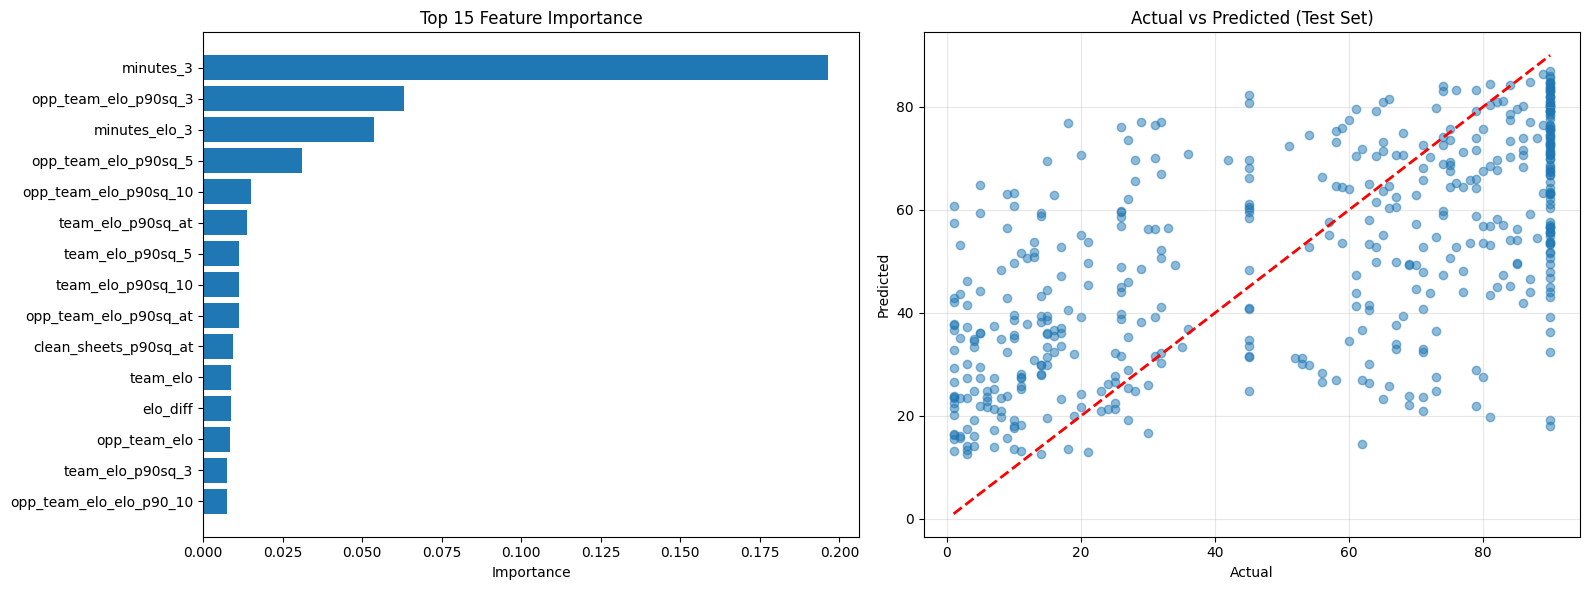

Cleaned df size: 8272/27834

Training Set Performance:
R² Score: 0.6718
RMSE: 18.3390
MAE: 15.1103

Test Set Performance:
R² Score: 0.3274
RMSE: 26.8962
MAE: 22.1083

Top 20 Feature Importances:
              feature  importance
            minutes_3    0.351428
 opp_team_elo_p90sq_3    0.026732
opp_team_elo_p90sq_10    0.020839
 opp_team_elo_p90sq_5    0.017106
           minutes_10    0.012815
               bps_10    0.012290
        minutes_elo_3    0.010693
       minutes_elo_10    0.008573
    minutes_elo_p90_5    0.008563
         opp_team_elo    0.008388
                bps_3    0.007849
clean_sheets_p90sq_at    0.007523
      xg_over_g_ratio    0.007471
       opp_team_elo_5    0.007138
       opp_team_elo_3    0.006926
    team_elo_p90sq_10    0.006853
opp_team_elo_p90sq_at    0.006774
goals_conceded_elo_10    0.006322
             elo_diff    0.006192
            minutes_5    0.006171


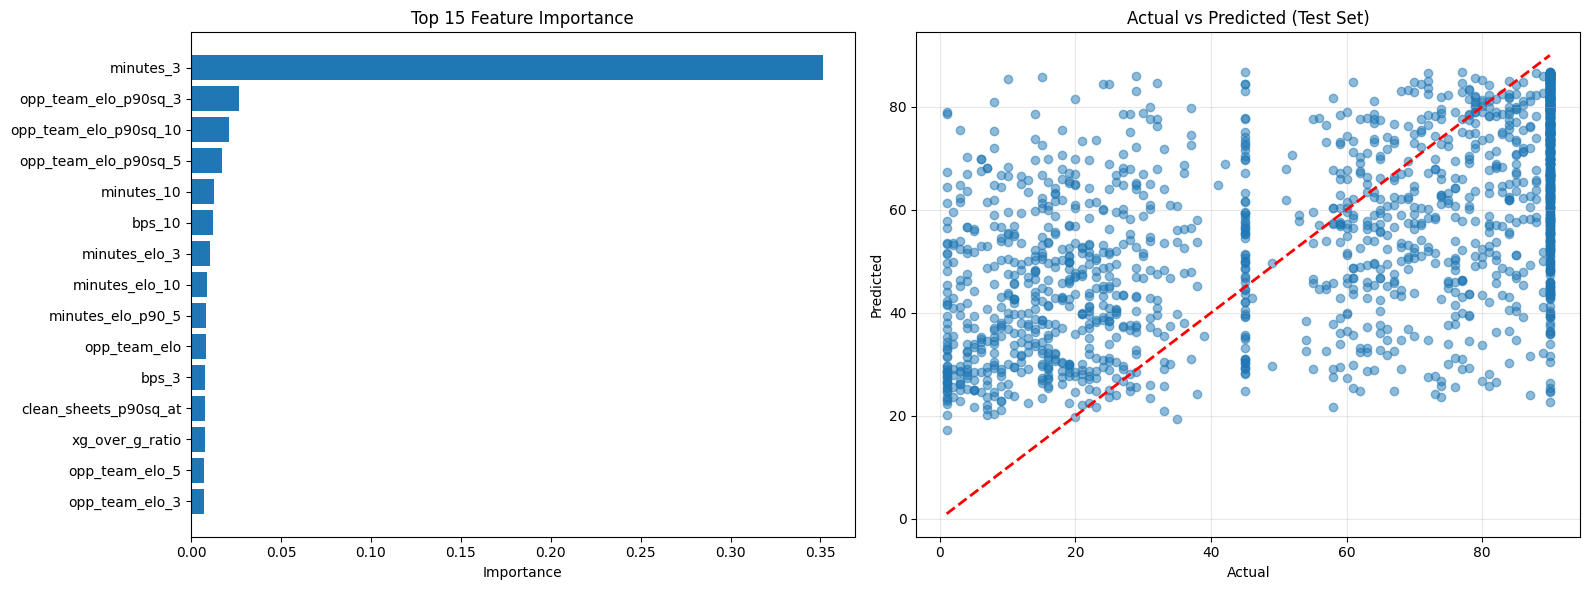

Cleaned df size: 5149/20045

Training Set Performance:
R² Score: 0.6821
RMSE: 16.4987
MAE: 12.3379

Test Set Performance:
R² Score: 0.2183
RMSE: 26.2227
MAE: 19.2479

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.126523
        team_elo_p90sq_3    0.059305
    opp_team_elo_p90sq_3    0.049118
   opp_team_elo_p90sq_10    0.024988
opp_team_elo_elo_p90sq_3    0.022265
    opp_team_elo_p90sq_5    0.014603
         xg_over_g_ratio    0.013678
           minutes_elo_3    0.010905
            opp_team_elo    0.010892
       team_elo_p90sq_10    0.010793
       xassists_p90sq_at    0.010441
         opp_team_elo_10    0.010345
            bps_p90sq_at    0.010063
          opp_team_elo_3    0.009455
                elo_diff    0.009122
   total_points_p90sq_10    0.008959
              minutes_10    0.008818
   opp_team_elo_p90sq_at    0.008555
 goals_conceded_p90sq_at    0.008536
          bonus_p90sq_at    0.008503


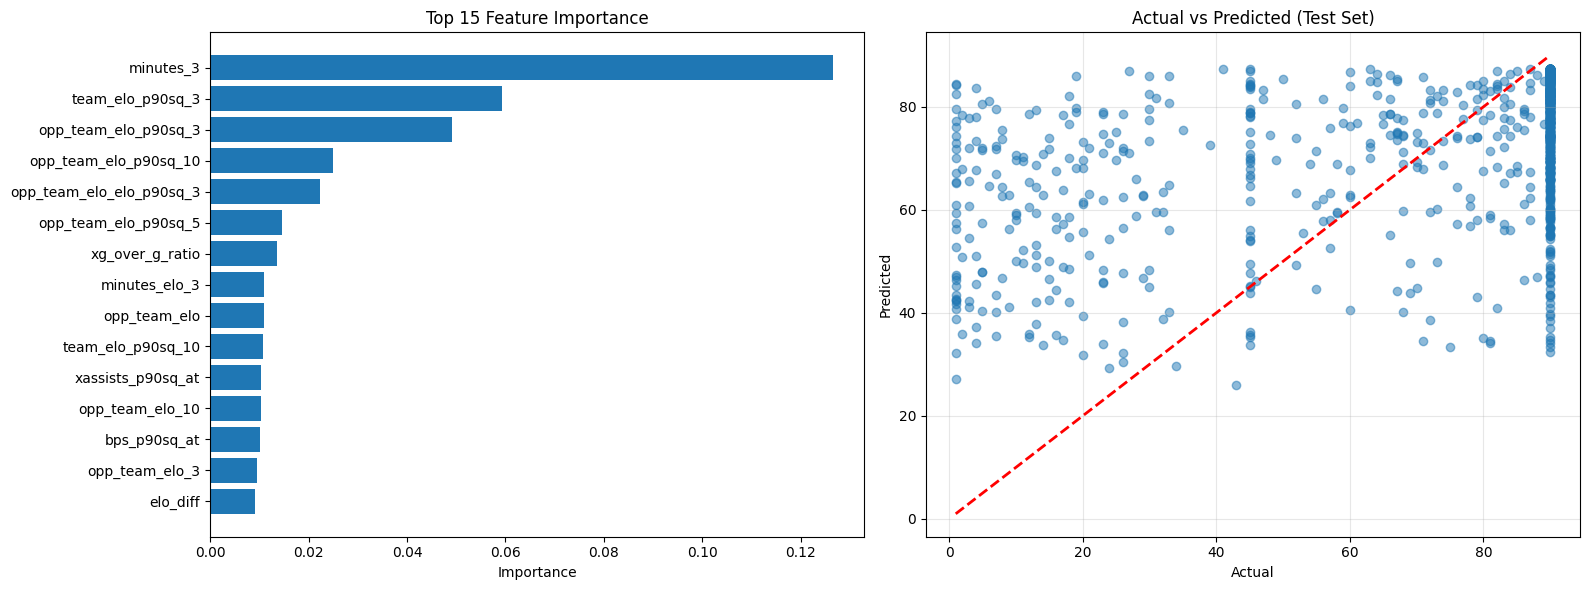

Cleaned df size: 3879/4142

Training Set Performance:
R² Score: 0.7013
RMSE: 2.8275
MAE: 0.5858

Test Set Performance:
R² Score: -0.1149
RMSE: 5.3373
MAE: 1.2139

Top 20 Feature Importances:
                    feature  importance
      opp_team_elo_p90sq_at    0.057137
                bps_p90sq_3    0.042419
               opp_team_elo    0.035598
                     bps_10    0.027677
               bps_p90sq_at    0.025841
                bps_p90sq_5    0.024578
          saves_elo_p90sq_3    0.022943
              minutes_elo_3    0.021929
             opp_team_elo_3    0.019451
             opp_team_elo_5    0.017557
             team_elo_elo_3    0.017198
          team_elo_p90sq_at    0.015823
            opp_team_elo_10    0.015395
                   elo_diff    0.014815
goals_conceded_elo_p90sq_10    0.013816
      total_points_p90sq_10    0.012891
    goals_conceded_p90sq_at    0.012562
   opp_team_elo_elo_p90sq_3    0.012139
      total_points_p90sq_at    0.012106
       te

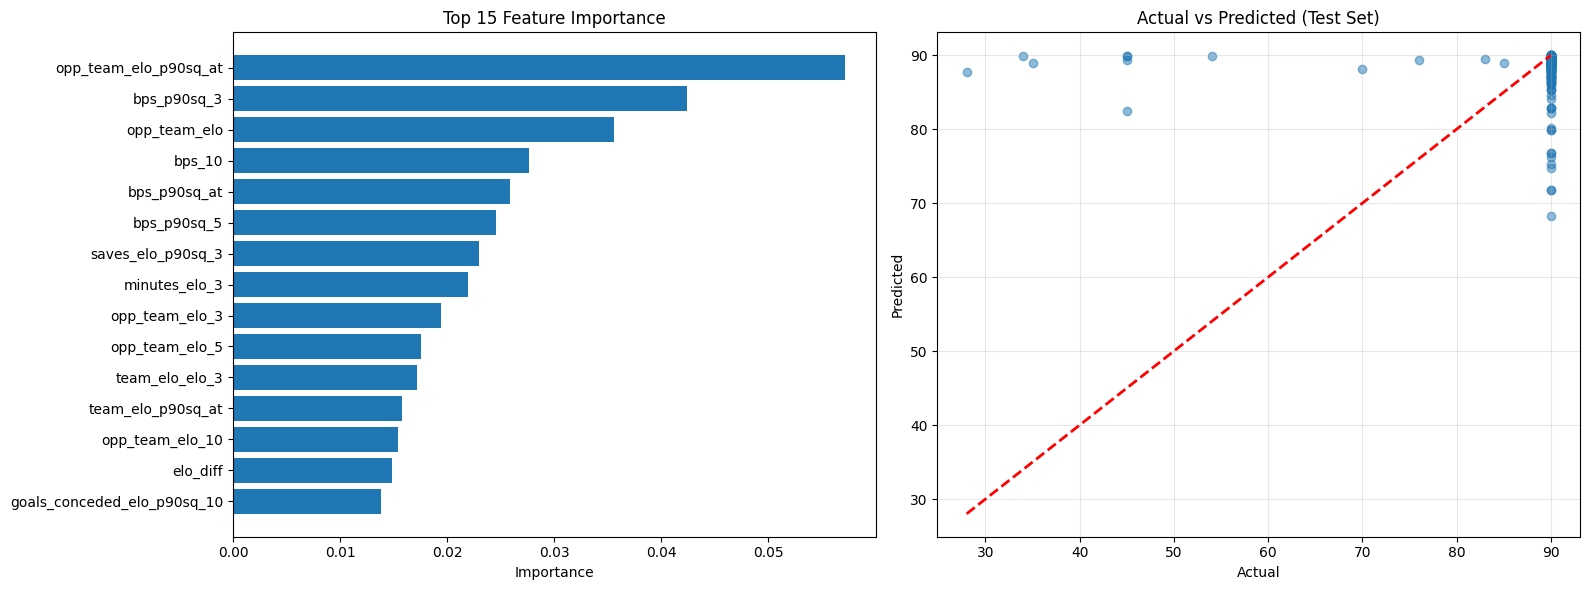

In [12]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2554/4278

Training Set Performance:
R² Score: 0.6350
RMSE: 0.2359
MAE: 0.1896

Test Set Performance:
R² Score: 0.0182
RMSE: 0.3834
MAE: 0.2911

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.036514
               elo_diff    0.024098
        xg_over_g_ratio    0.021765
           opp_team_elo    0.019888
               team_elo    0.019886
        opp_team_elo_10    0.017180
         opp_team_elo_3    0.015922
         bonus_p90sq_at    0.015464
    goals_scored_elo_10    0.014989
         opp_team_elo_5    0.014910
goals_conceded_p90sq_at    0.012812
   opp_team_elo_p90sq_3    0.012773
       team_elo_p90sq_5    0.012485
   opp_team_elo_p90sq_5    0.012294
  opp_team_elo_p90sq_10    0.011912
  total_points_p90sq_10    0.011100
  clean_sheets_p90sq_at    0.010969
       team_elo_p90sq_3    0.010767
           bps_p90sq_at    0.010664
      team_elo_p90sq_at    0.010043


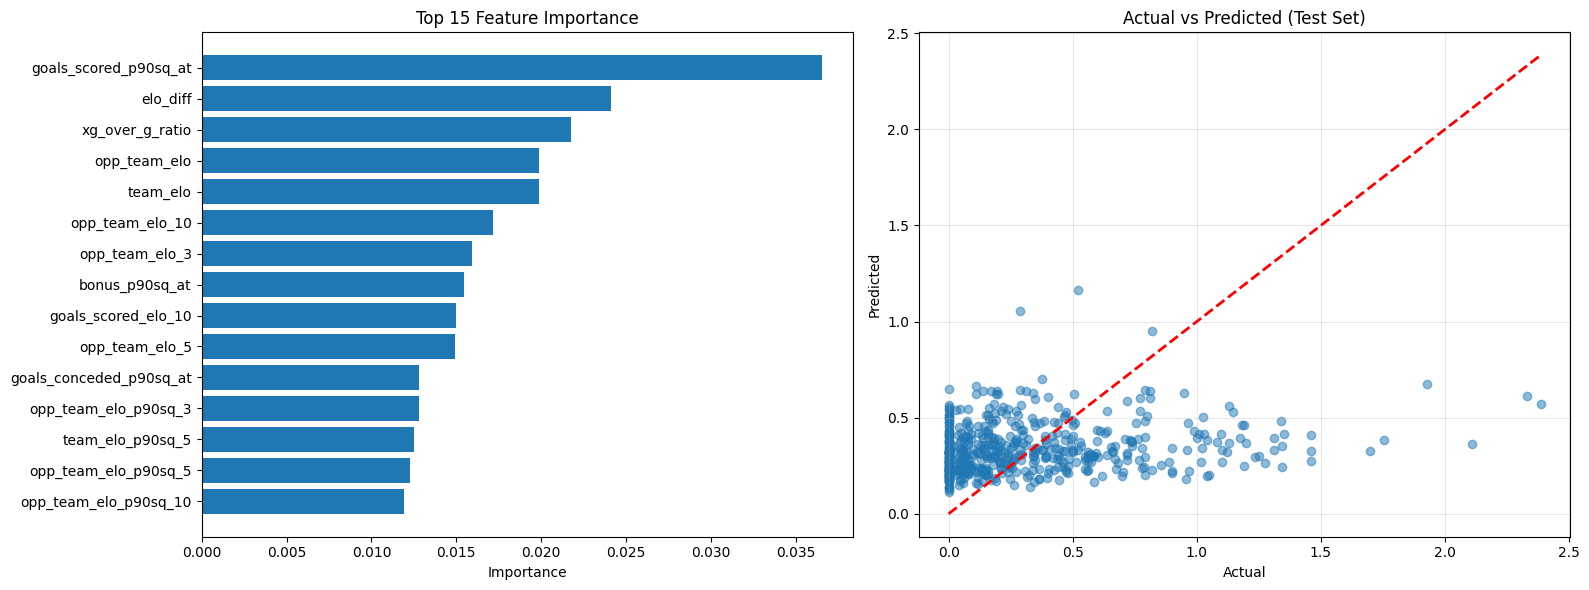

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 11881/18296

Training Set Performance:
R² Score: 0.3968
RMSE: 0.1740
MAE: 0.1183

Test Set Performance:
R² Score: 0.0638
RMSE: 0.2061
MAE: 0.1351

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.151629
           opp_team_elo    0.041395
         bonus_p90sq_at    0.026469
        opp_team_elo_10    0.017799
    goals_scored_elo_10    0.017763
               elo_diff    0.017719
         opp_team_elo_3    0.015709
  clean_sheets_p90sq_at    0.014549
           bps_p90sq_at    0.014476
         opp_team_elo_5    0.014296
       bps_elo_p90sq_10    0.012435
    total_points_elo_10    0.011908
  total_points_p90sq_at    0.011432
           bps_p90sq_10    0.010622
      team_elo_p90sq_at    0.010336
goals_conceded_p90sq_at    0.009804
                 bps_10    0.009417
  goals_conceded_elo_10    0.009349
  opp_team_elo_p90sq_10    0.009052
             bps_elo_10    0.008845


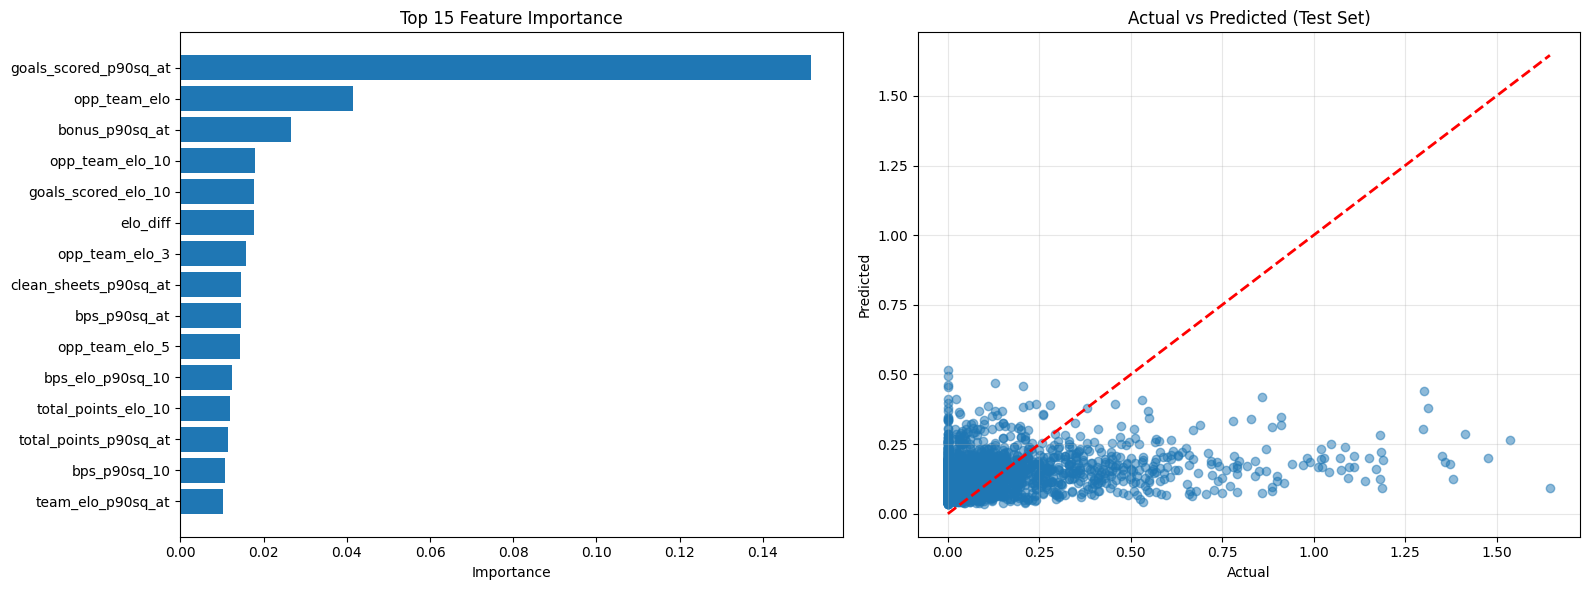

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10176/16372

Training Set Performance:
R² Score: 0.2715
RMSE: 0.0920
MAE: 0.0555

Test Set Performance:
R² Score: -0.0272
RMSE: 0.1024
MAE: 0.0601

Top 20 Feature Importances:
                    feature  importance
               opp_team_elo    0.040721
             opp_team_elo_3    0.038308
      goals_scored_p90sq_at    0.035625
          team_elo_p90sq_at    0.023150
      total_points_p90sq_at    0.019130
      goals_conceded_elo_10    0.018240
        goals_scored_elo_10    0.017694
              minutes_elo_5    0.016781
     opp_team_elo_elo_p90_5    0.016407
         total_points_elo_5    0.016097
            opp_team_elo_10    0.015908
               bps_p90sq_at    0.015272
                   elo_diff    0.014749
    goals_conceded_p90sq_at    0.013921
      opp_team_elo_p90sq_10    0.013517
         total_points_p90_3    0.013082
             opp_team_elo_5    0.013023
goals_conceded_elo_p90sq_10    0.012620
 

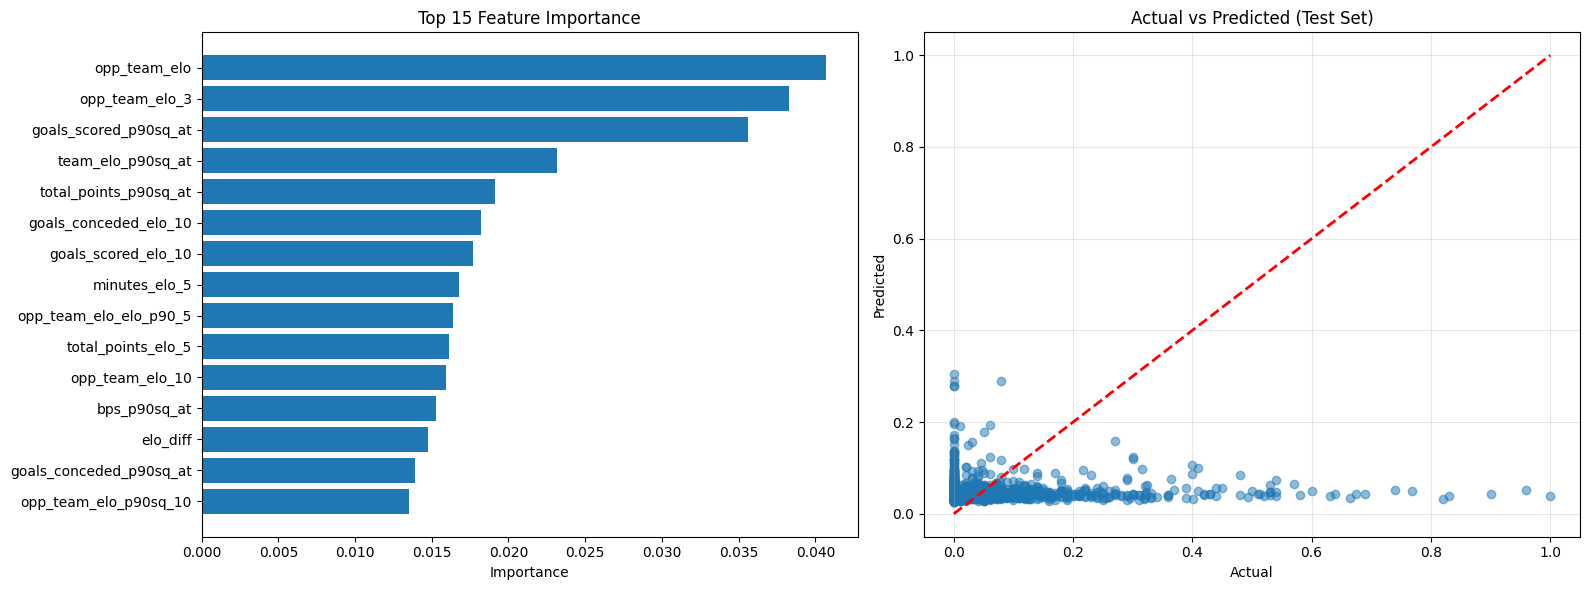

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2746/4560

Training Set Performance:
R² Score: 0.5313
RMSE: 0.0800
MAE: 0.0542

Test Set Performance:
R² Score: 0.0067
RMSE: 0.1306
MAE: 0.0784

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.039610
                elo_diff    0.028483
          opp_team_elo_3    0.024571
           bps_elo_p90_5    0.023516
       minutes_elo_p90_5    0.021416
    total_points_p90sq_3    0.018087
total_points_elo_p90sq_3    0.015648
       minutes_elo_p90_3    0.015563
              bps_elo_10    0.014867
  opp_team_elo_elo_p90_3    0.013663
         xg_over_g_ratio    0.013162
 opp_team_elo_elo_p90_10    0.012973
          opp_team_elo_5    0.012216
          total_points_3    0.012036
             bonus_elo_5    0.012002
    opp_team_elo_p90sq_5    0.011683
            bps_p90sq_at    0.011377
         opp_team_elo_10    0.011260
goals_scored_elo_p90sq_5    0.010572
      total_points_p90

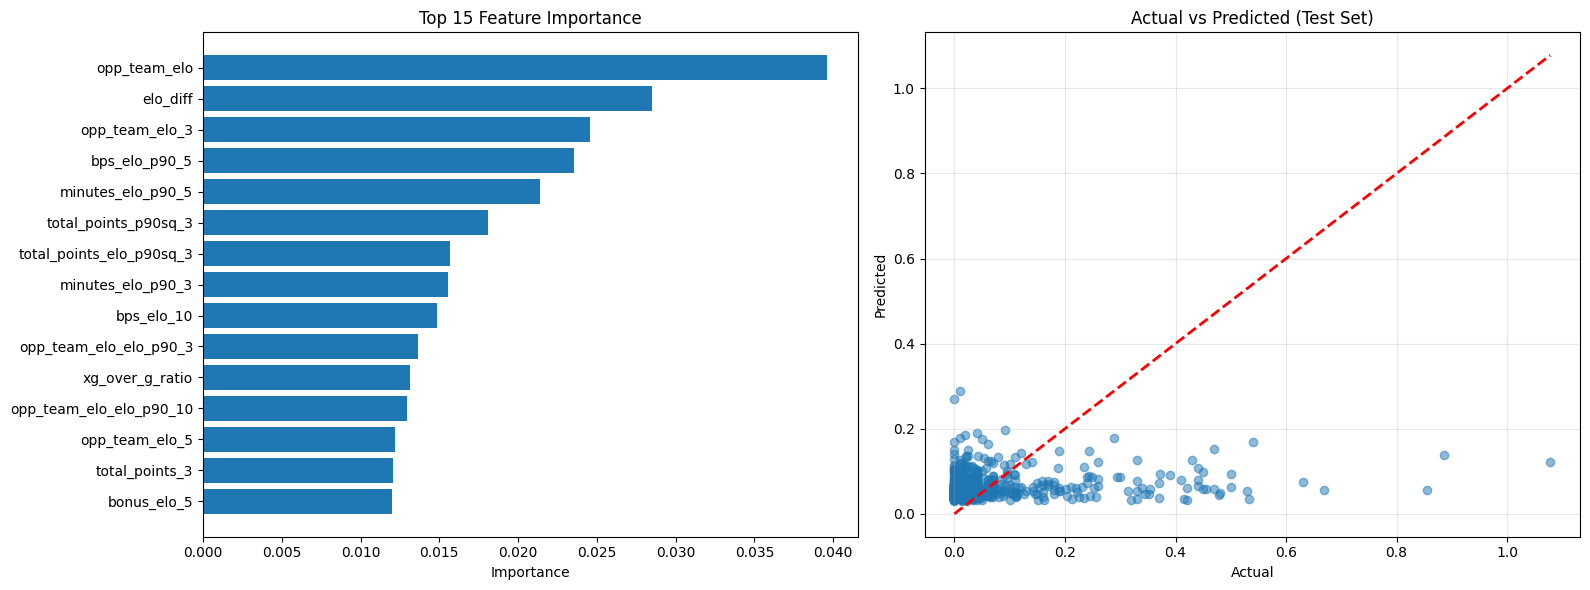

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12302/18921

Training Set Performance:
R² Score: 0.4178
RMSE: 0.1239
MAE: 0.0879

Test Set Performance:
R² Score: 0.0813
RMSE: 0.1589
MAE: 0.1075

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.090184
         bonus_p90sq_at    0.067030
             bps_elo_10    0.035154
    total_points_elo_10    0.031995
           opp_team_elo    0.027234
  goals_scored_p90sq_at    0.021800
        opp_team_elo_10    0.016777
  total_points_p90sq_at    0.016159
                 bps_10    0.015266
         opp_team_elo_5    0.014249
         opp_team_elo_3    0.013874
           bps_p90sq_at    0.012220
               team_elo    0.012068
  clean_sheets_p90sq_at    0.010878
goals_conceded_p90sq_at    0.010176
      team_elo_p90sq_at    0.009820
  opp_team_elo_p90sq_at    0.009751
             bps_p90_10    0.009716
          bps_elo_p90_5    0.009056
        bps_elo_p90sq_5    0.008357


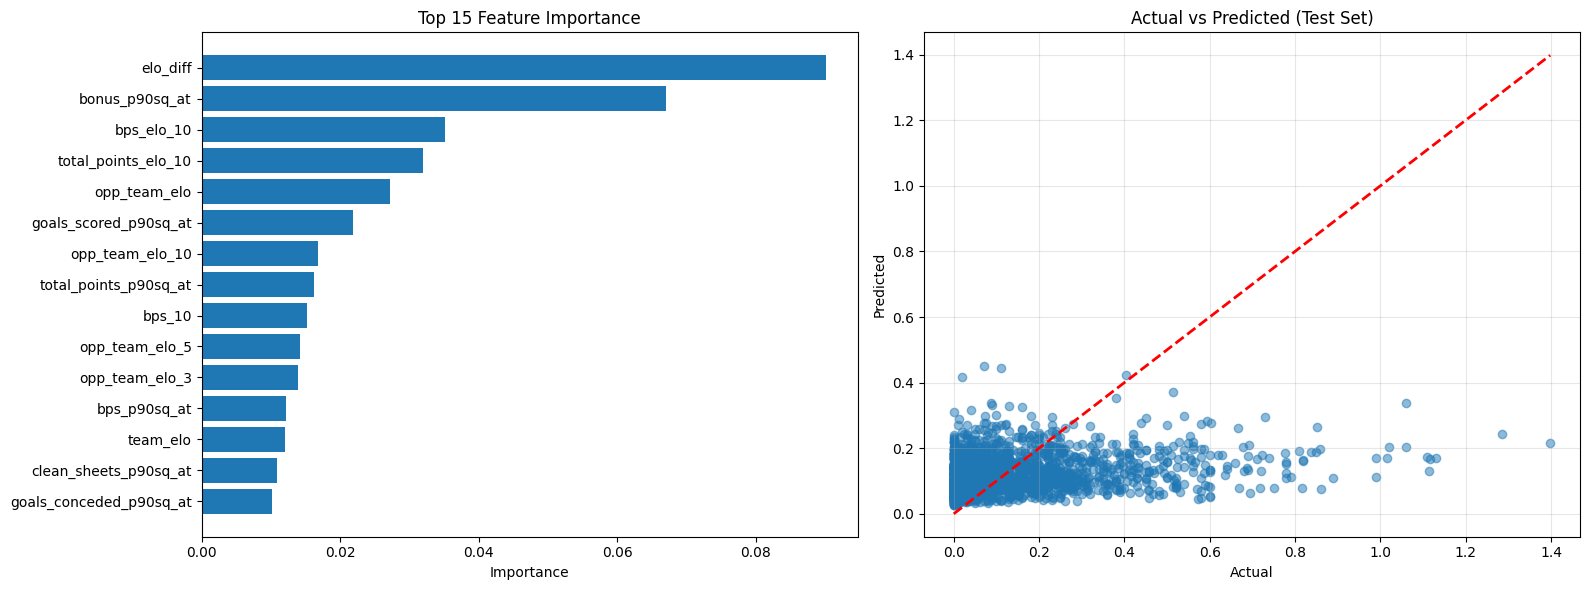

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10372/16692

Training Set Performance:
R² Score: 0.3811
RMSE: 0.0828
MAE: 0.0512

Test Set Performance:
R² Score: 0.0478
RMSE: 0.0999
MAE: 0.0583

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.103909
               elo_diff    0.032996
           opp_team_elo    0.030961
    minutes_elo_p90sq_3    0.023729
goals_conceded_p90sq_at    0.021614
         opp_team_elo_3    0.018586
  clean_sheets_p90sq_at    0.018277
               team_elo    0.016679
        opp_team_elo_10    0.016417
   goals_conceded_elo_3    0.015955
                  bps_3    0.015525
    total_points_p90_10    0.014772
                 bps_10    0.013808
  goals_scored_p90sq_at    0.013464
            bps_p90sq_5    0.012469
            bps_p90sq_3    0.011761
  opp_team_elo_p90sq_at    0.011658
     team_elo_elo_p90_3    0.011388
           bps_p90sq_at    0.011183
      team_elo_p90sq_at    0.010935


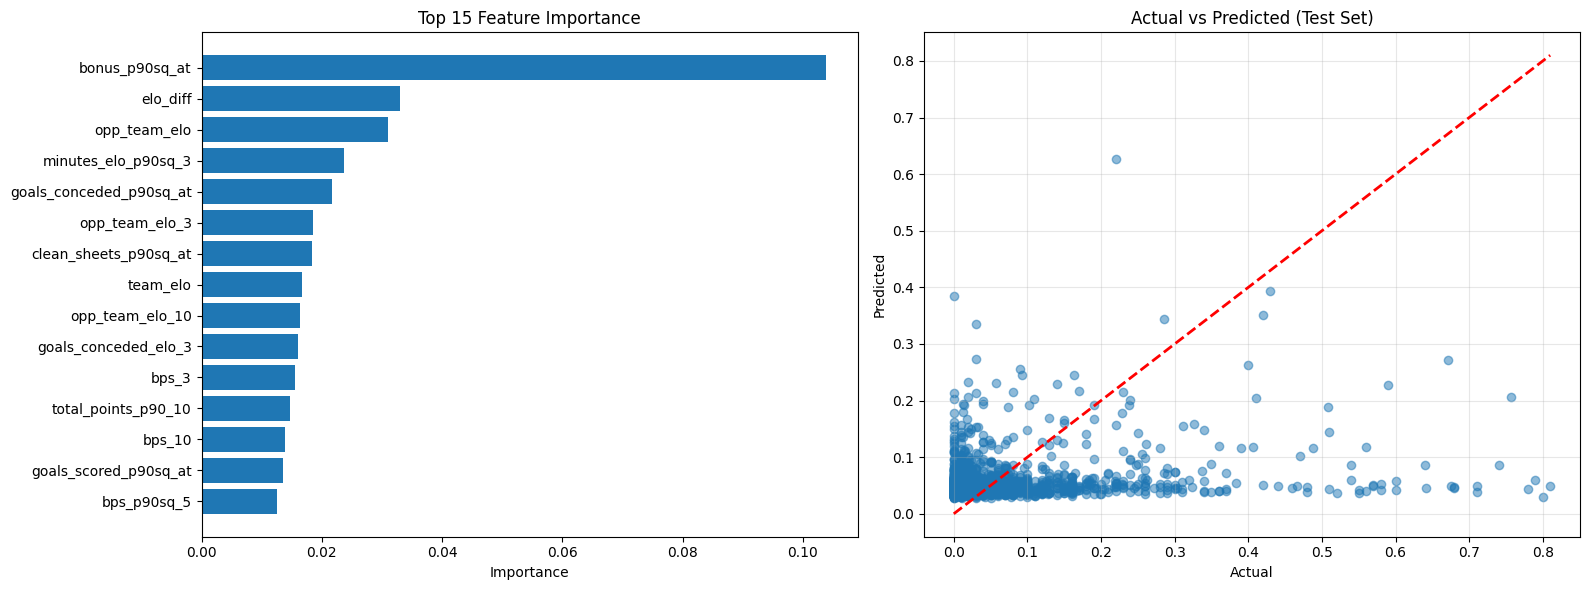

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2746/4560

Training Set Performance:
R² Score: 0.6780
RMSE: 0.5270
MAE: 0.4276

Test Set Performance:
R² Score: 0.1351
RMSE: 0.8813
MAE: 0.6836

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.149510
               opp_team_elo    0.056126
            xg_over_g_ratio    0.040881
      clean_sheets_p90sq_at    0.025644
            opp_team_elo_10    0.021616
    goals_conceded_p90sq_at    0.014956
             opp_team_elo_3    0.012718
             opp_team_elo_5    0.012328
         minutes_elo_p90_10    0.011116
             bonus_p90sq_at    0.010407
                 minutes_10    0.009179
          minutes_elo_p90_3    0.009060
       goals_conceded_elo_5    0.008941
      goals_scored_p90sq_at    0.008844
      goals_conceded_elo_10    0.008365
         opp_team_elo_elo_5    0.008232
goals_conceded_elo_p90sq_10    0.008202
                team_elo_10    0.0

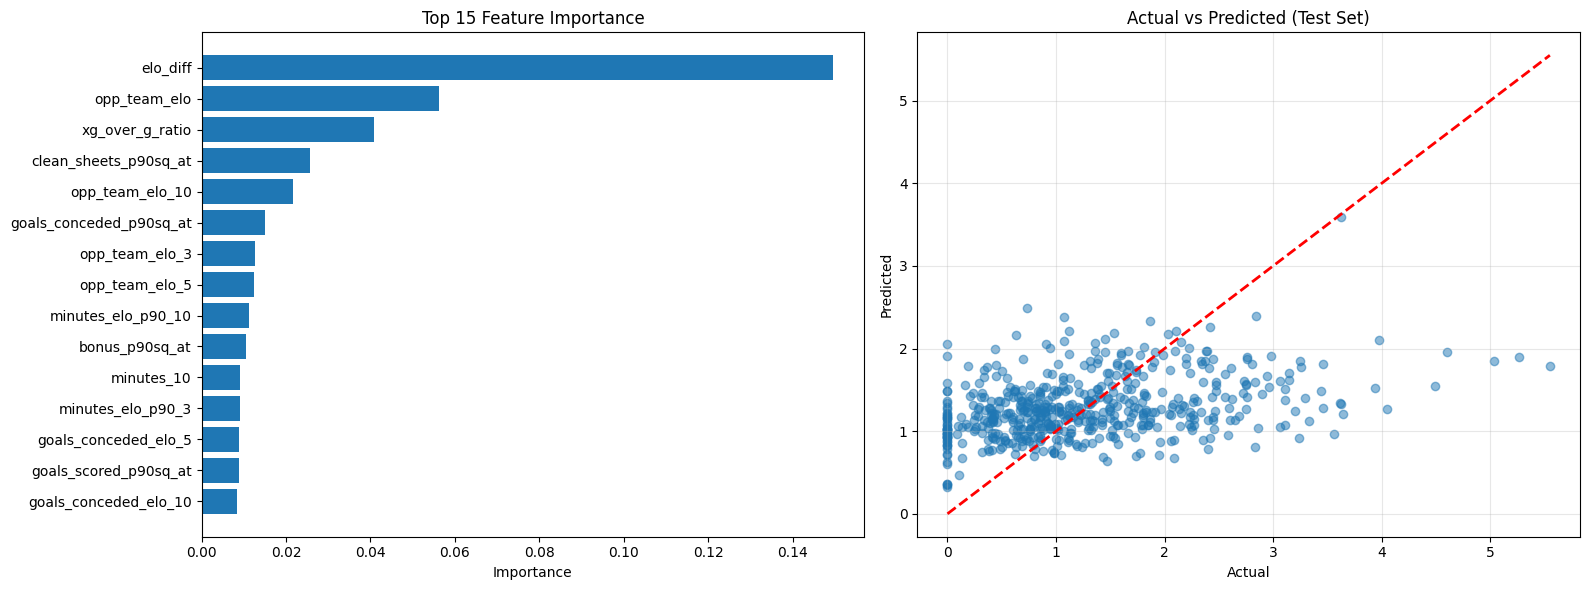

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12302/18921

Training Set Performance:
R² Score: 0.5335
RMSE: 0.6384
MAE: 0.5084

Test Set Performance:
R² Score: 0.3136
RMSE: 0.7903
MAE: 0.6164

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.252935
         opp_team_elo    0.069590
       opp_team_elo_5    0.035355
      opp_team_elo_10    0.032656
             team_elo    0.027667
       opp_team_elo_3    0.025079
           team_elo_5    0.021680
          team_elo_10    0.020774
           team_elo_3    0.016596
   opp_team_elo_elo_5    0.015754
clean_sheets_p90sq_at    0.015302
  minutes_elo_p90sq_3    0.015193
    minutes_elo_p90_3    0.014912
       team_elo_elo_5    0.014855
       team_elo_elo_3    0.014701
   opp_team_elo_elo_3    0.014319
  opp_team_elo_elo_10    0.014160
    minutes_elo_p90_5    0.011134
  minutes_elo_p90sq_5    0.010531
      team_elo_elo_10    0.010336


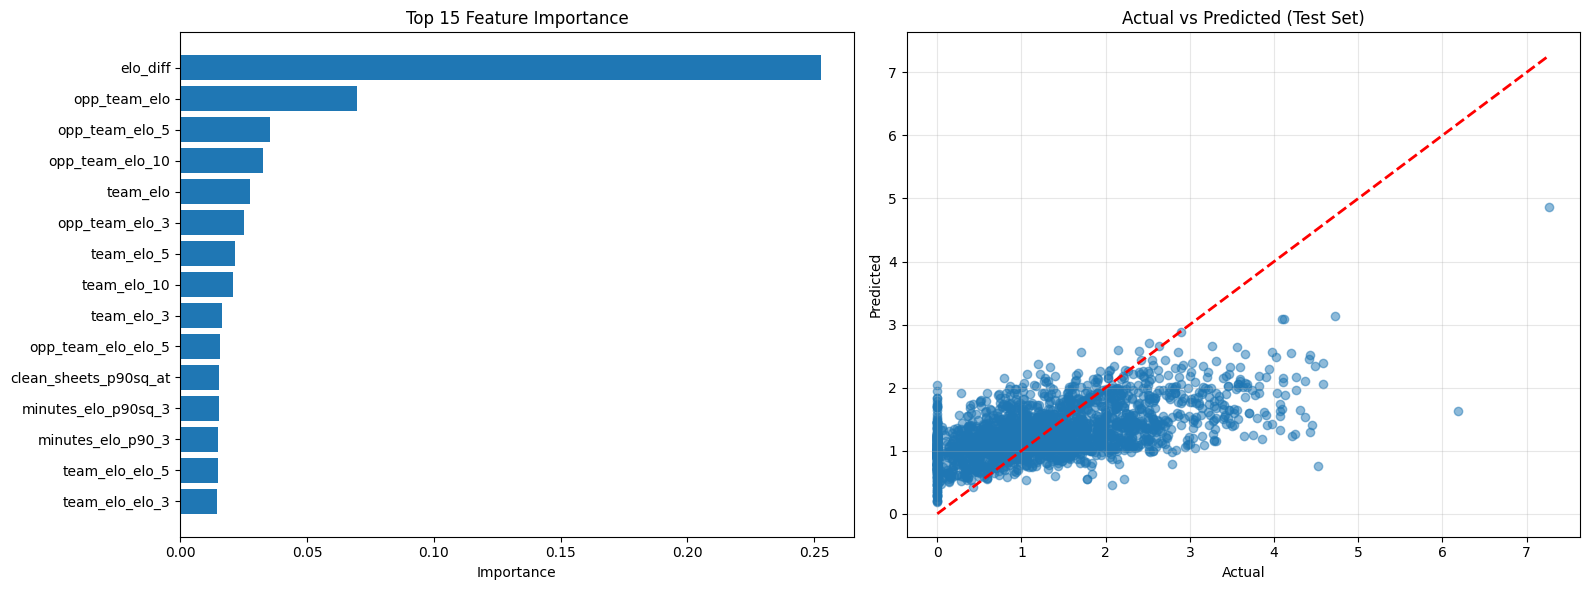

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10372/16692

Training Set Performance:
R² Score: 0.5817
RMSE: 0.6117
MAE: 0.4871

Test Set Performance:
R² Score: 0.3175
RMSE: 0.7497
MAE: 0.5882

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.189326
           opp_team_elo    0.091622
         opp_team_elo_5    0.033275
    opp_team_elo_elo_10    0.030106
        opp_team_elo_10    0.027148
            team_elo_10    0.022826
               team_elo    0.021215
         opp_team_elo_3    0.020590
             team_elo_5    0.020194
  clean_sheets_p90sq_at    0.018658
     opp_team_elo_elo_3    0.017808
     opp_team_elo_elo_5    0.016290
         team_elo_elo_3    0.016183
             team_elo_3    0.015836
goals_conceded_p90sq_at    0.015065
         team_elo_elo_5    0.014856
    minutes_elo_p90sq_3    0.011349
        team_elo_elo_10    0.011129
      minutes_elo_p90_3    0.010621
  opp_team_elo_p90sq_at    0.009

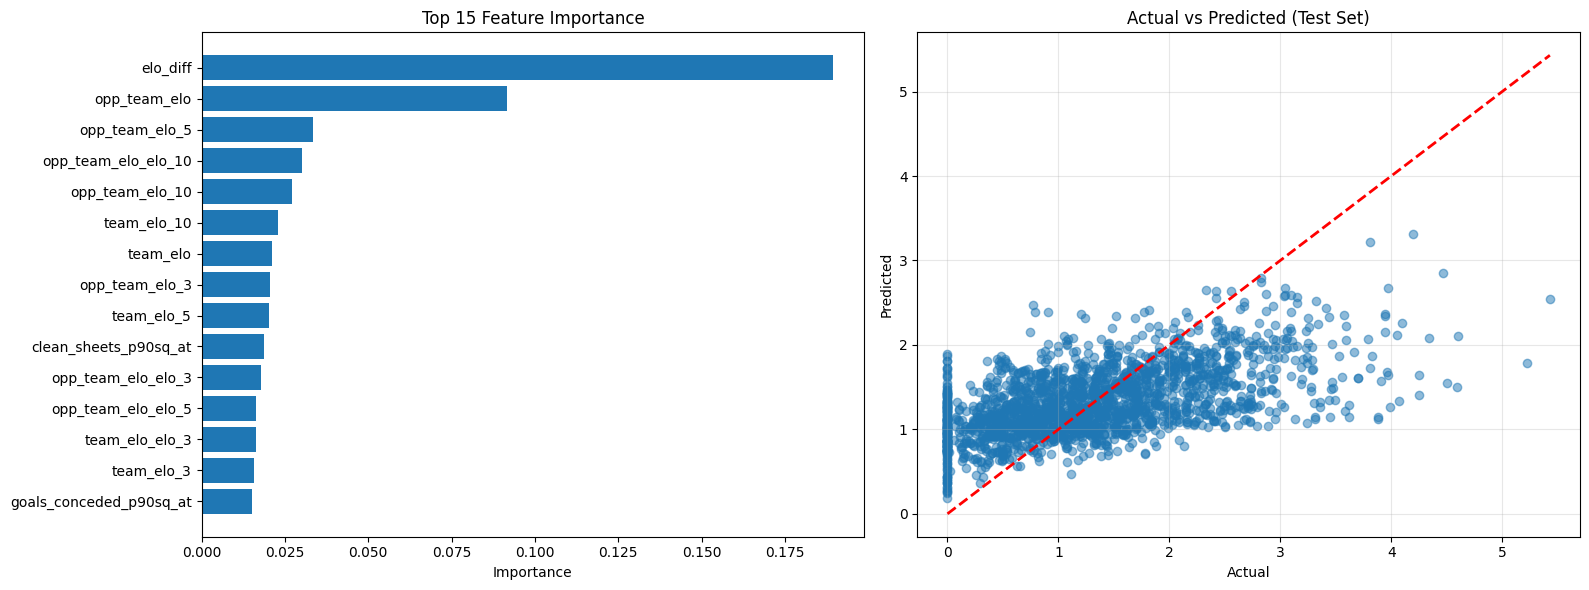

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2544/4080

Training Set Performance:
R² Score: 0.6952
RMSE: 0.5127
MAE: 0.4170

Test Set Performance:
R² Score: 0.1431
RMSE: 0.8314
MAE: 0.6458

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.162366
           opp_team_elo    0.044929
         saves_p90sq_at    0.029853
  opp_team_elo_p90sq_at    0.025993
      team_elo_p90sq_at    0.022059
  opp_team_elo_p90sq_10    0.022006
        opp_team_elo_10    0.019005
goals_conceded_p90sq_at    0.018772
           bps_p90sq_at    0.015786
     saves_elo_p90sq_10    0.015689
         opp_team_elo_5    0.013324
  total_points_p90sq_at    0.012862
          saves_p90sq_5    0.012456
         saves_p90sq_10    0.011725
         bonus_p90sq_at    0.011418
   opp_team_elo_p90sq_3    0.011096
         opp_team_elo_3    0.011015
   opp_team_elo_p90sq_5    0.010499
  clean_sheets_p90sq_at    0.010475
          saves_p90sq_3    0.010265

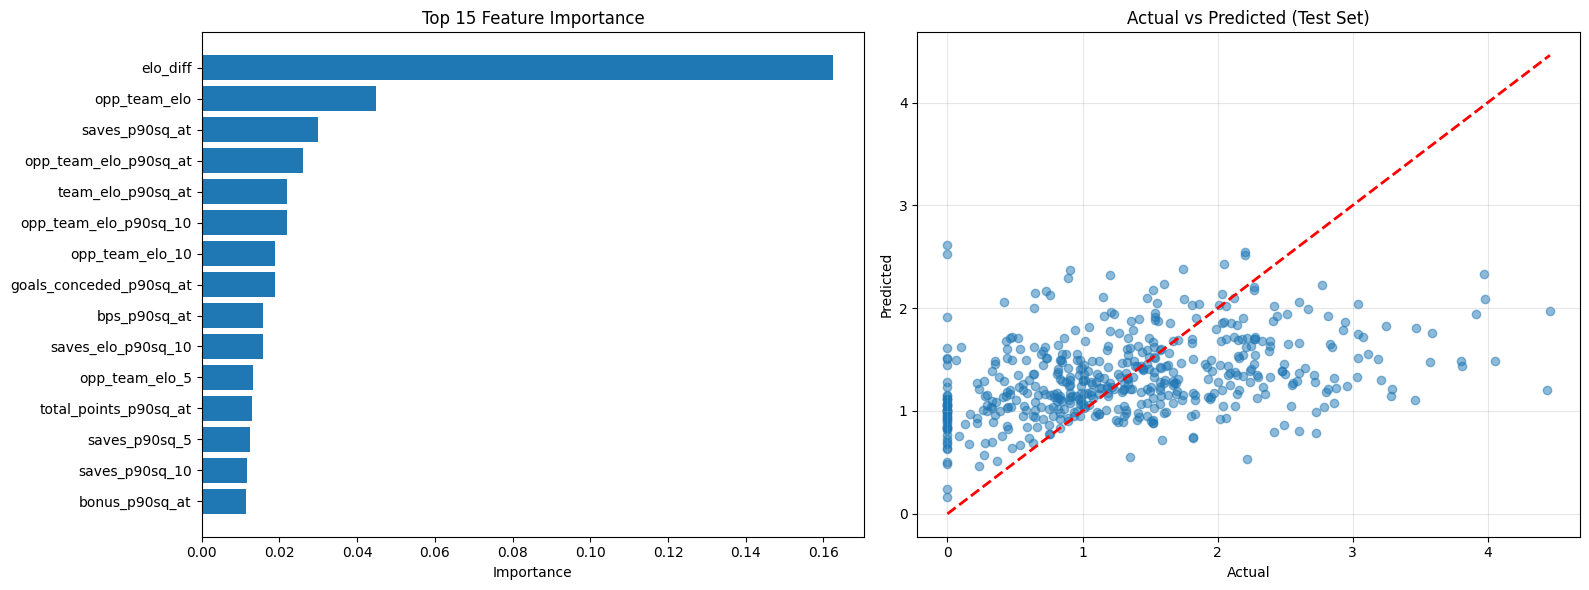

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4058/4560

Training Set Performance:
R² Score: 0.4784
RMSE: 13.3915
MAE: 10.8637

Test Set Performance:
R² Score: -0.0133
RMSE: 18.5119
MAE: 14.7845

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.071457
             opp_team_elo    0.028926
          opp_team_elo_10    0.024168
           opp_team_elo_3    0.016159
           opp_team_elo_5    0.015899
       opp_team_elo_elo_5    0.014901
  goals_conceded_p90sq_at    0.014510
           bonus_p90sq_at    0.014452
               bps_elo_10    0.013762
    clean_sheets_p90sq_at    0.012963
      minutes_elo_p90sq_5    0.012383
     minutes_elo_p90sq_10    0.012068
              bps_p90sq_5    0.011498
    total_points_p90sq_at    0.011369
    opp_team_elo_p90sq_at    0.011255
                bps_elo_3    0.011130
        minutes_elo_p90_3    0.010962
clean_sheets_elo_p90sq_10    0.010368
        minutes_elo_p90_5    0.010294
     goal

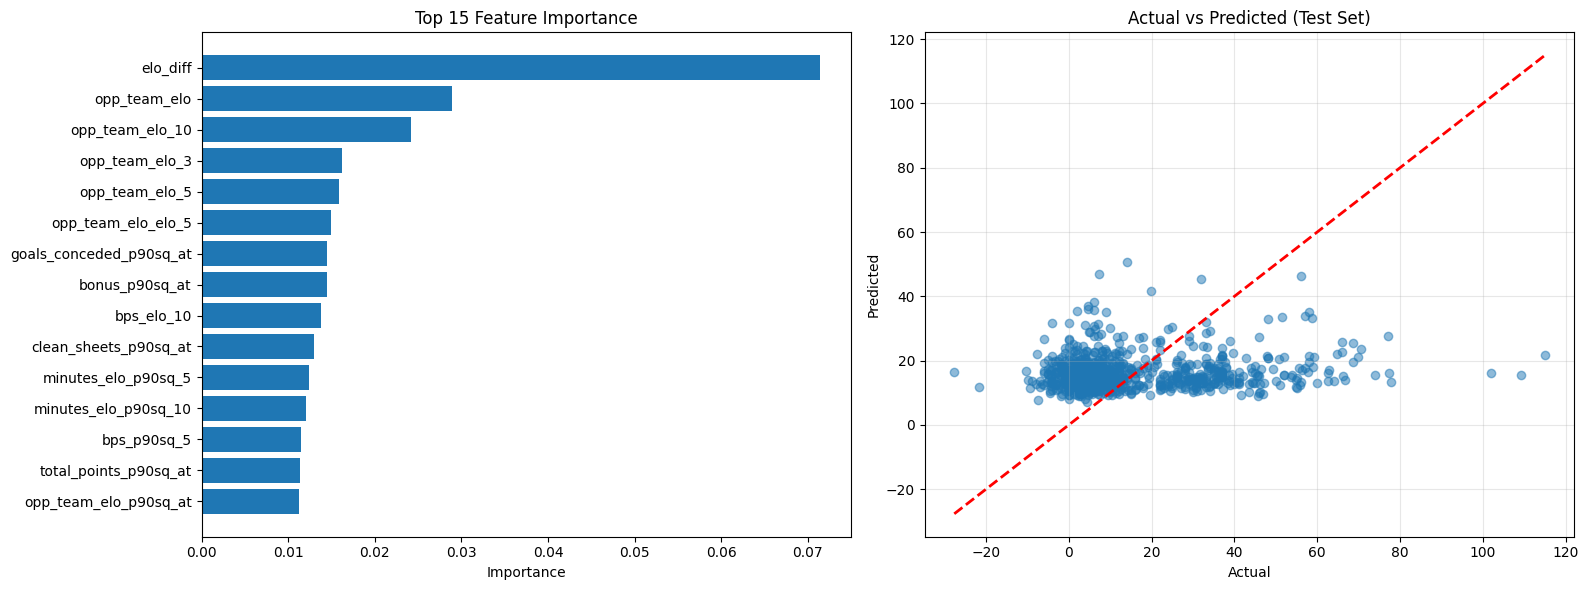

target=bps_per90, MID_bps_predictor
Cleaned df size: 18316/18921

Training Set Performance:
R² Score: 0.3223
RMSE: 9.4518
MAE: 7.1687

Test Set Performance:
R² Score: 0.0597
RMSE: 11.0324
MAE: 8.0682

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.129798
             bps_elo_10    0.035272
                 bps_10    0.024084
         bonus_p90sq_at    0.020097
           opp_team_elo    0.018762
        opp_team_elo_10    0.017890
         opp_team_elo_5    0.015354
                  bps_5    0.014785
         opp_team_elo_3    0.013706
  goals_scored_p90sq_at    0.013501
           bps_p90sq_at    0.010597
              bps_elo_5    0.009669
goals_conceded_p90sq_10    0.009216
              bps_p90_3    0.009202
goals_conceded_p90sq_at    0.008980
              bps_elo_3    0.008895
            bps_p90sq_5    0.008532
  clean_sheets_p90sq_at    0.008451
    total_points_elo_10    0.008397
      team_elo_p90sq_at    0.008385


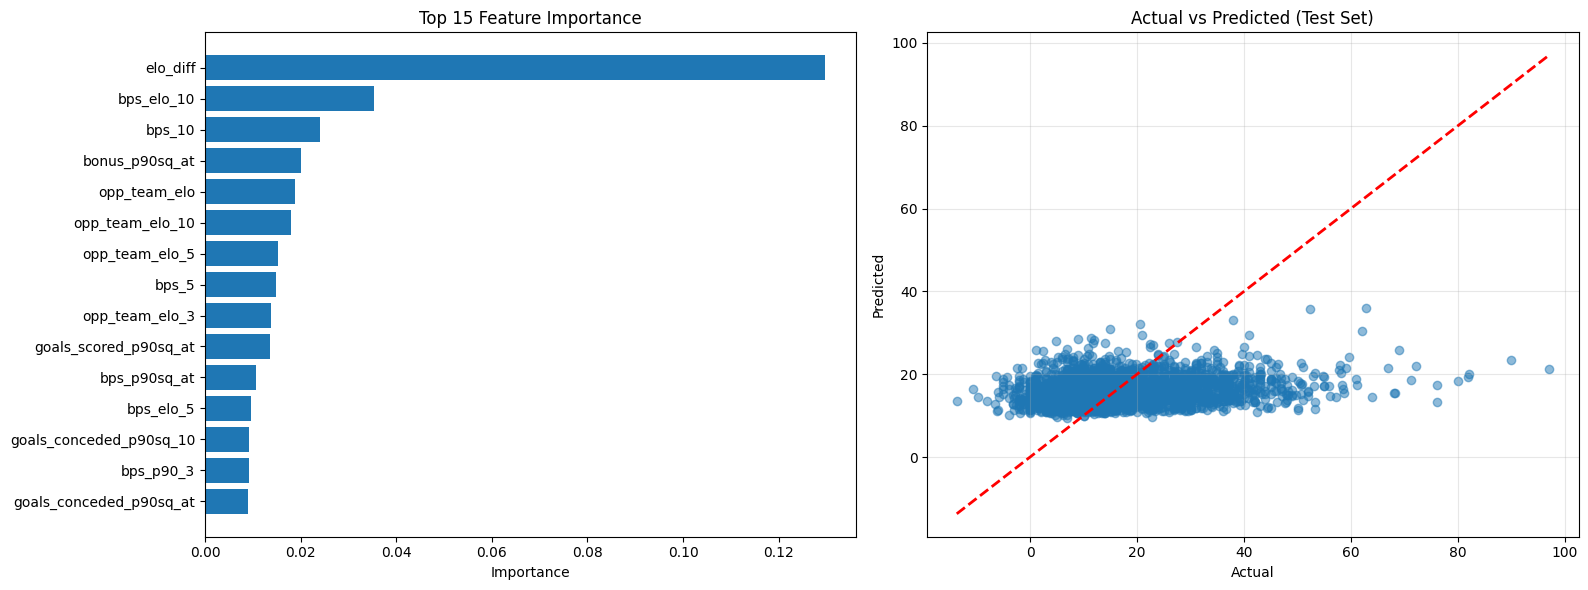

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15699/16692

Training Set Performance:
R² Score: 0.4236
RMSE: 7.5045
MAE: 6.0116

Test Set Performance:
R² Score: 0.1571
RMSE: 9.0019
MAE: 7.0725

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.226775
           opp_team_elo    0.030935
        opp_team_elo_10    0.026125
         opp_team_elo_5    0.022085
         opp_team_elo_3    0.018116
         bonus_p90sq_at    0.016661
            team_elo_10    0.013496
               team_elo    0.012150
            bps_p90sq_5    0.011870
goals_conceded_p90sq_at    0.011029
  clean_sheets_p90sq_at    0.010720
           bps_p90sq_at    0.010522
             bps_p90_10    0.010393
        bps_elo_p90sq_3    0.008501
             team_elo_5    0.008495
      minutes_elo_p90_3    0.008474
  goals_scored_p90sq_at    0.008393
          minutes_elo_3    0.008183
       bps_elo_p90sq_10    0.008071
   opp_team_elo_p90sq_3    0.008024


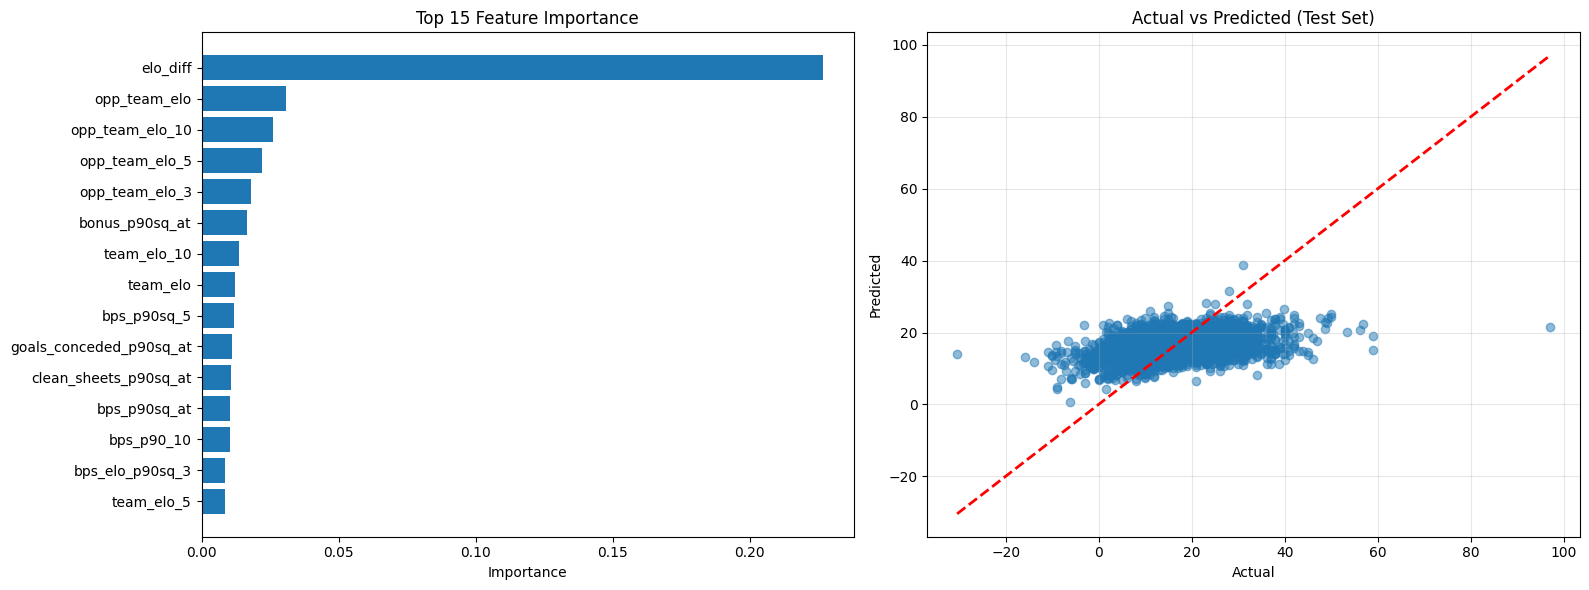

target=bps_per90, GK_bps_predictor
Cleaned df size: 3842/4080

Training Set Performance:
R² Score: 0.5596
RMSE: 5.9399
MAE: 4.8170

Test Set Performance:
R² Score: 0.0251
RMSE: 8.4539
MAE: 6.7644

Top 20 Feature Importances:
                    feature  importance
               bps_p90sq_10    0.037970
                 bps_p90_10    0.031448
            opp_team_elo_10    0.029686
               opp_team_elo    0.025767
               bps_p90sq_at    0.022413
                   elo_diff    0.020039
             saves_p90sq_10    0.019848
                     bps_10    0.018308
      opp_team_elo_p90sq_10    0.017933
                bps_p90sq_3    0.017033
      total_points_p90sq_10    0.016949
      opp_team_elo_p90sq_at    0.016903
         saves_elo_p90sq_10    0.015260
             bonus_p90sq_at    0.014766
             saves_p90sq_at    0.014324
    goals_conceded_p90sq_at    0.014263
          saves_elo_p90sq_3    0.014179
goals_conceded_elo_p90sq_10    0.013965
          saves

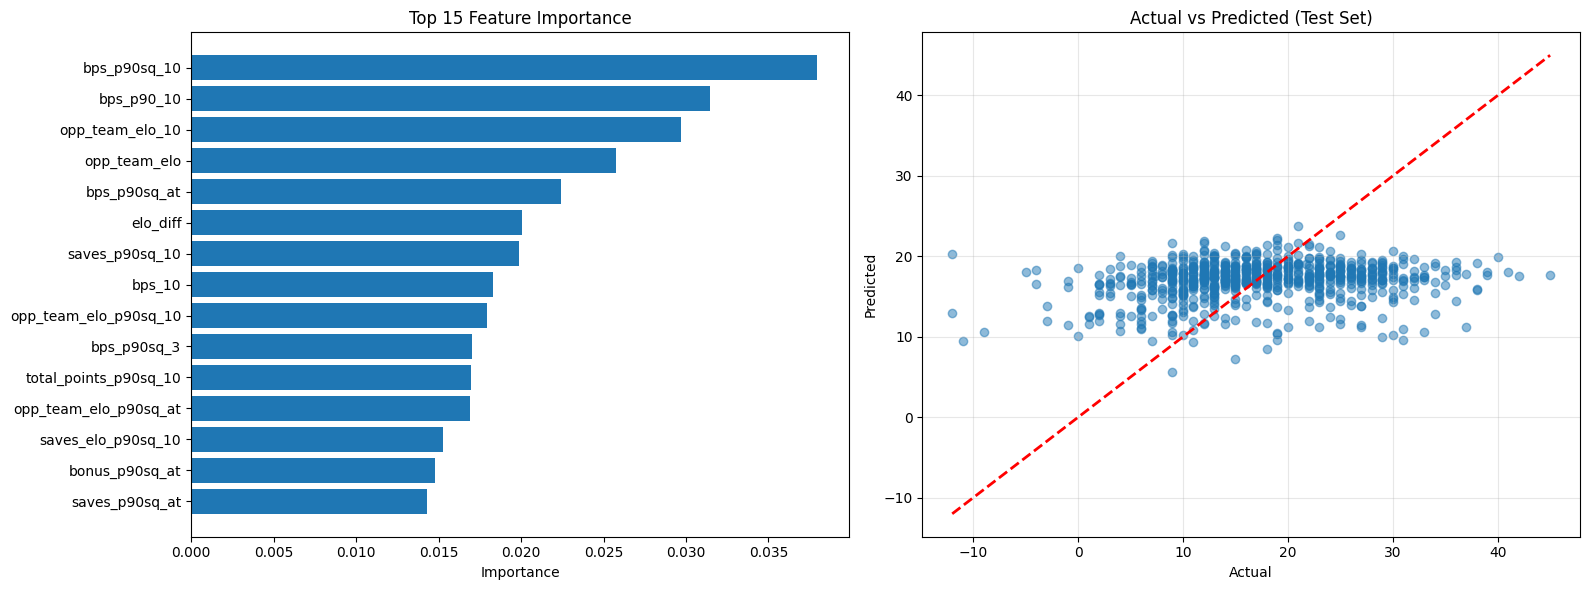

In [16]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3842/4099

Training Set Performance:
R² Score: 0.5895
RMSE: 1.2630
MAE: 1.0230

Test Set Performance:
R² Score: 0.0422
RMSE: 1.8854
MAE: 1.4861

Top 20 Feature Importances:
                 feature  importance
                elo_diff    0.148165
            opp_team_elo    0.019977
          saves_p90sq_at    0.019127
         opp_team_elo_10    0.017438
          opp_team_elo_5    0.016343
            bps_p90sq_at    0.014950
   opp_team_elo_p90sq_at    0.014313
       team_elo_p90sq_at    0.014196
 goals_conceded_p90sq_at    0.013562
          saves_p90sq_10    0.013503
          opp_team_elo_3    0.012174
       saves_elo_p90sq_5    0.012028
      saves_elo_p90sq_10    0.011972
total_points_elo_p90sq_5    0.011961
          bonus_p90sq_at    0.011369
   opp_team_elo_p90sq_10    0.011071
         bps_elo_p90sq_5    0.010991
   total_points_p90sq_at    0.010717
    opp_team_elo_p90sq_3    0.010580
total_points_elo_p90sq_3    0.0

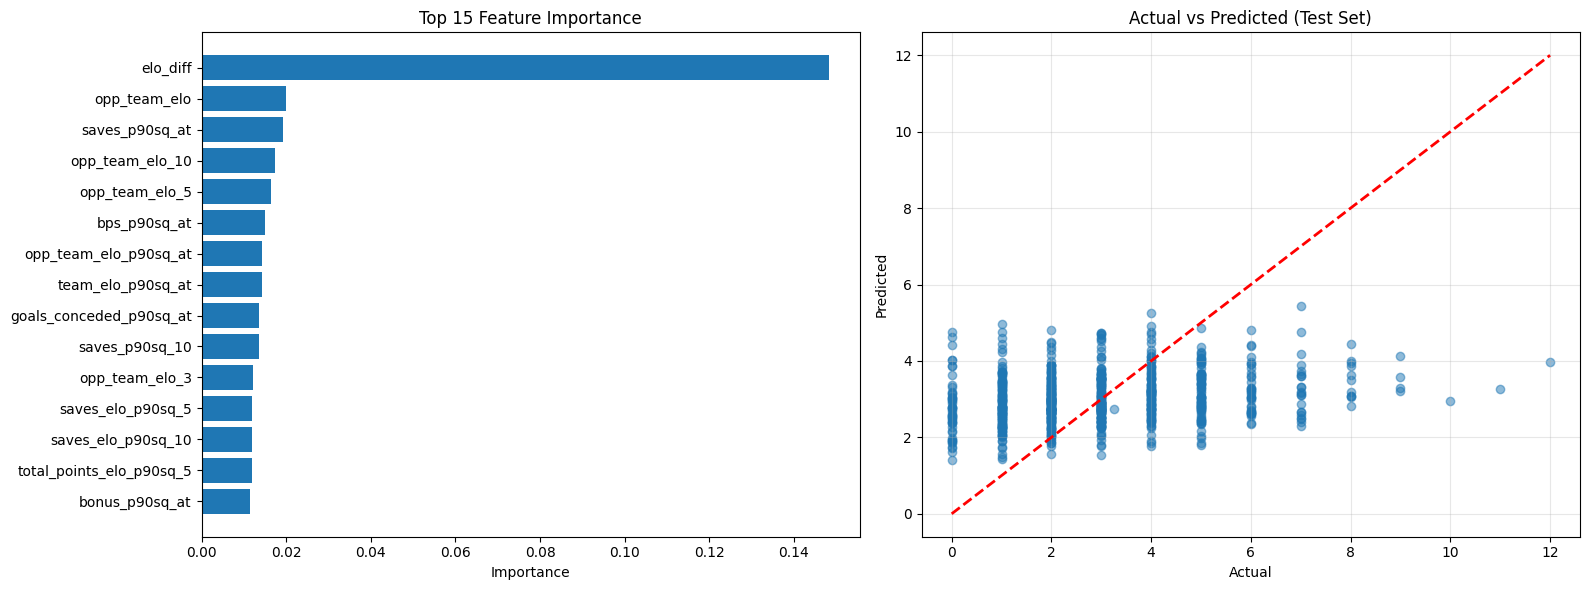

In [17]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 541/5040

Training Set Performance:
R² Score: 0.8063
RMSE: 1.2360
MAE: 0.9824

Test Set Performance:
R² Score: 0.0883
RMSE: 2.5223
MAE: 2.0116

Top 20 Feature Importances:
                feature  importance
  clean_sheets_p90sq_at    0.045688
   total_points_p90sq_3    0.029900
  goals_scored_p90sq_at    0.027392
         opp_team_elo_5    0.027245
  goals_conceded_p90_10    0.025326
        opp_team_elo_10    0.020300
  opp_team_elo_p90sq_at    0.018714
       team_elo_p90sq_5    0.017142
   opp_team_elo_p90sq_5    0.017103
           opp_team_elo    0.016721
goals_conceded_p90sq_at    0.016326
     minutes_elo_p90_10    0.015861
  total_points_p90sq_at    0.015083
         bonus_p90sq_at    0.015072
         opp_team_elo_3    0.014845
  goals_conceded_elo_10    0.013146
           bps_p90sq_at    0.012955
            bps_p90sq_5    0.012835
               team_elo    0.011792
    total_points_p90_10    0.0113

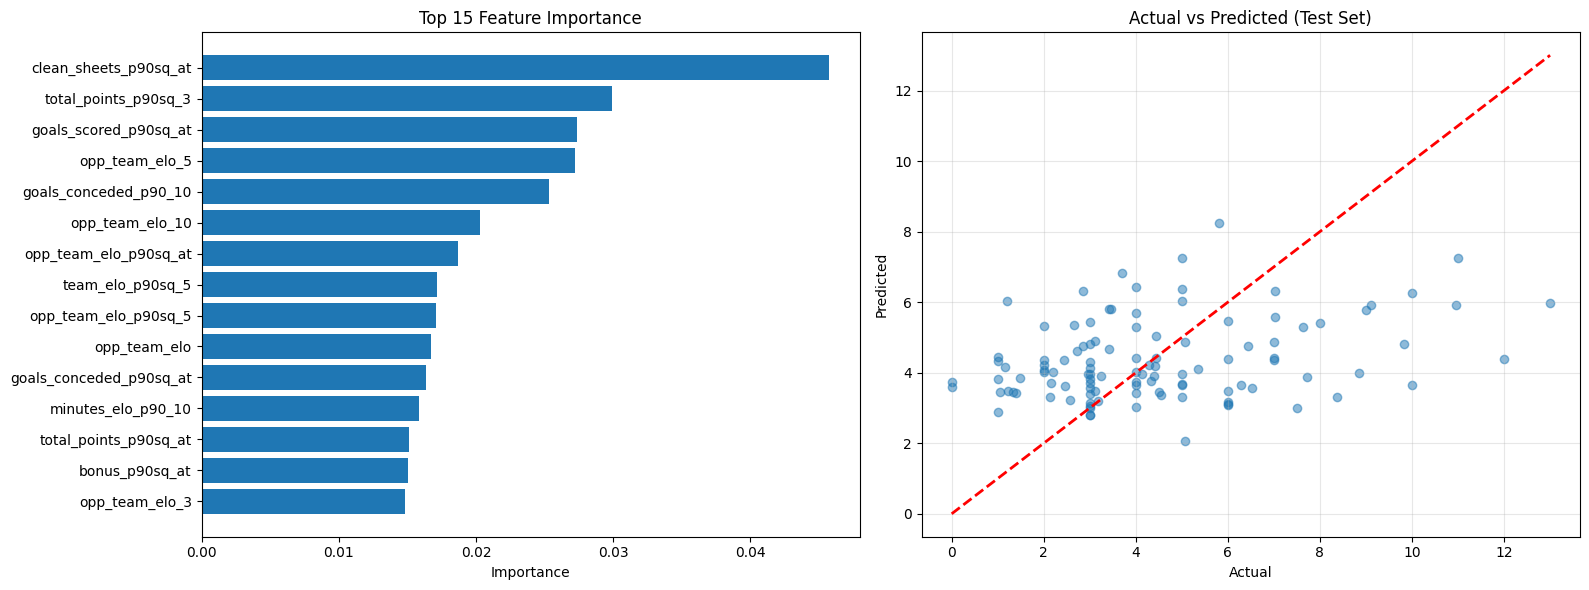

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2554/20808

Training Set Performance:
R² Score: 0.7071
RMSE: 2.2817
MAE: 1.8394

Test Set Performance:
R² Score: 0.1307
RMSE: 3.9585
MAE: 3.1686

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.096093
    goals_conceded_p90sq_at    0.039533
             bonus_p90sq_at    0.027049
      total_points_p90sq_at    0.021798
      goals_conceded_elo_10    0.019311
          team_elo_p90sq_at    0.017050
               bps_p90sq_at    0.015426
      clean_sheets_p90sq_at    0.014882
goals_conceded_elo_p90sq_10    0.014319
                   elo_diff    0.014104
       opp_team_elo_p90sq_3    0.013395
               opp_team_elo    0.013212
             opp_team_elo_5    0.012405
             opp_team_elo_3    0.011704
           team_elo_p90sq_3    0.011534
      opp_team_elo_p90sq_at    0.011391
           team_elo_p90sq_5    0.010635
                   team_elo    

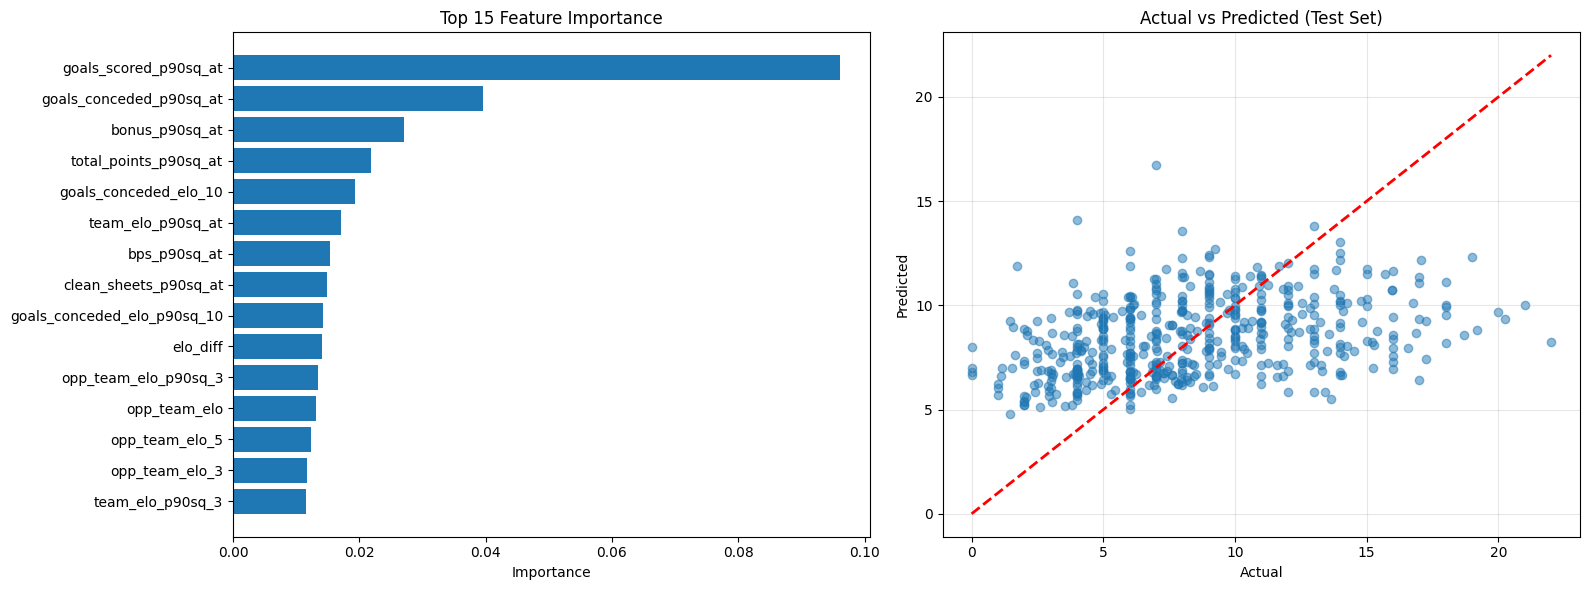

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2141/17637

Training Set Performance:
R² Score: 0.6636
RMSE: 2.2492
MAE: 1.8318

Test Set Performance:
R² Score: 0.0729
RMSE: 3.6509
MAE: 2.9321

Top 20 Feature Importances:
                feature  importance
  opp_team_elo_p90sq_at    0.027417
           opp_team_elo    0.021829
goals_conceded_p90sq_at    0.019530
  opp_team_elo_p90sq_10    0.017989
      team_elo_p90sq_at    0.017457
  total_points_p90sq_at    0.017334
         bonus_p90sq_at    0.016742
        opp_team_elo_10    0.016402
   opp_team_elo_p90sq_5    0.015883
         opp_team_elo_3    0.015861
        bps_elo_p90sq_3    0.015107
               elo_diff    0.014684
  goals_conceded_elo_10    0.014249
           bps_p90sq_at    0.013681
            bps_p90sq_3    0.013641
   opp_team_elo_p90sq_3    0.013054
         opp_team_elo_5    0.012967
  goals_scored_p90sq_at    0.012752
opp_team_elo_elo_p90_10    0.012469
   minutes_elo_p90sq_10    0.01

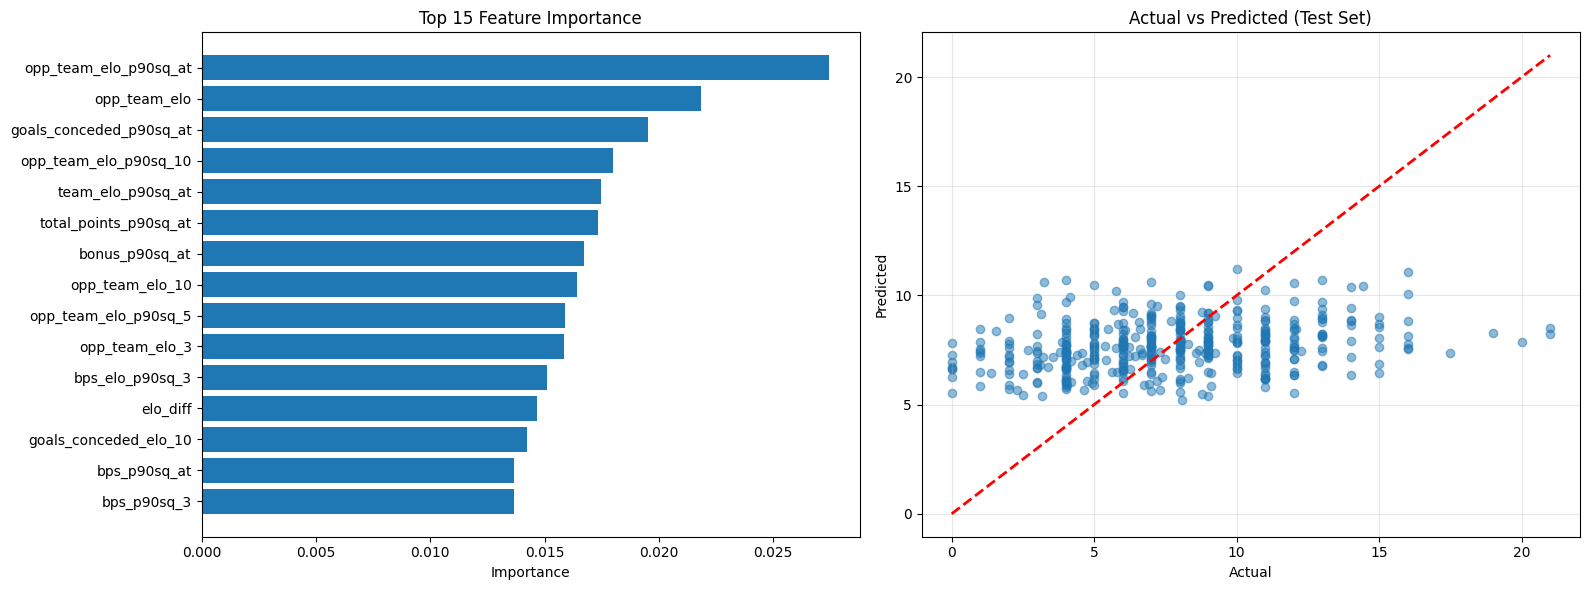

In [18]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

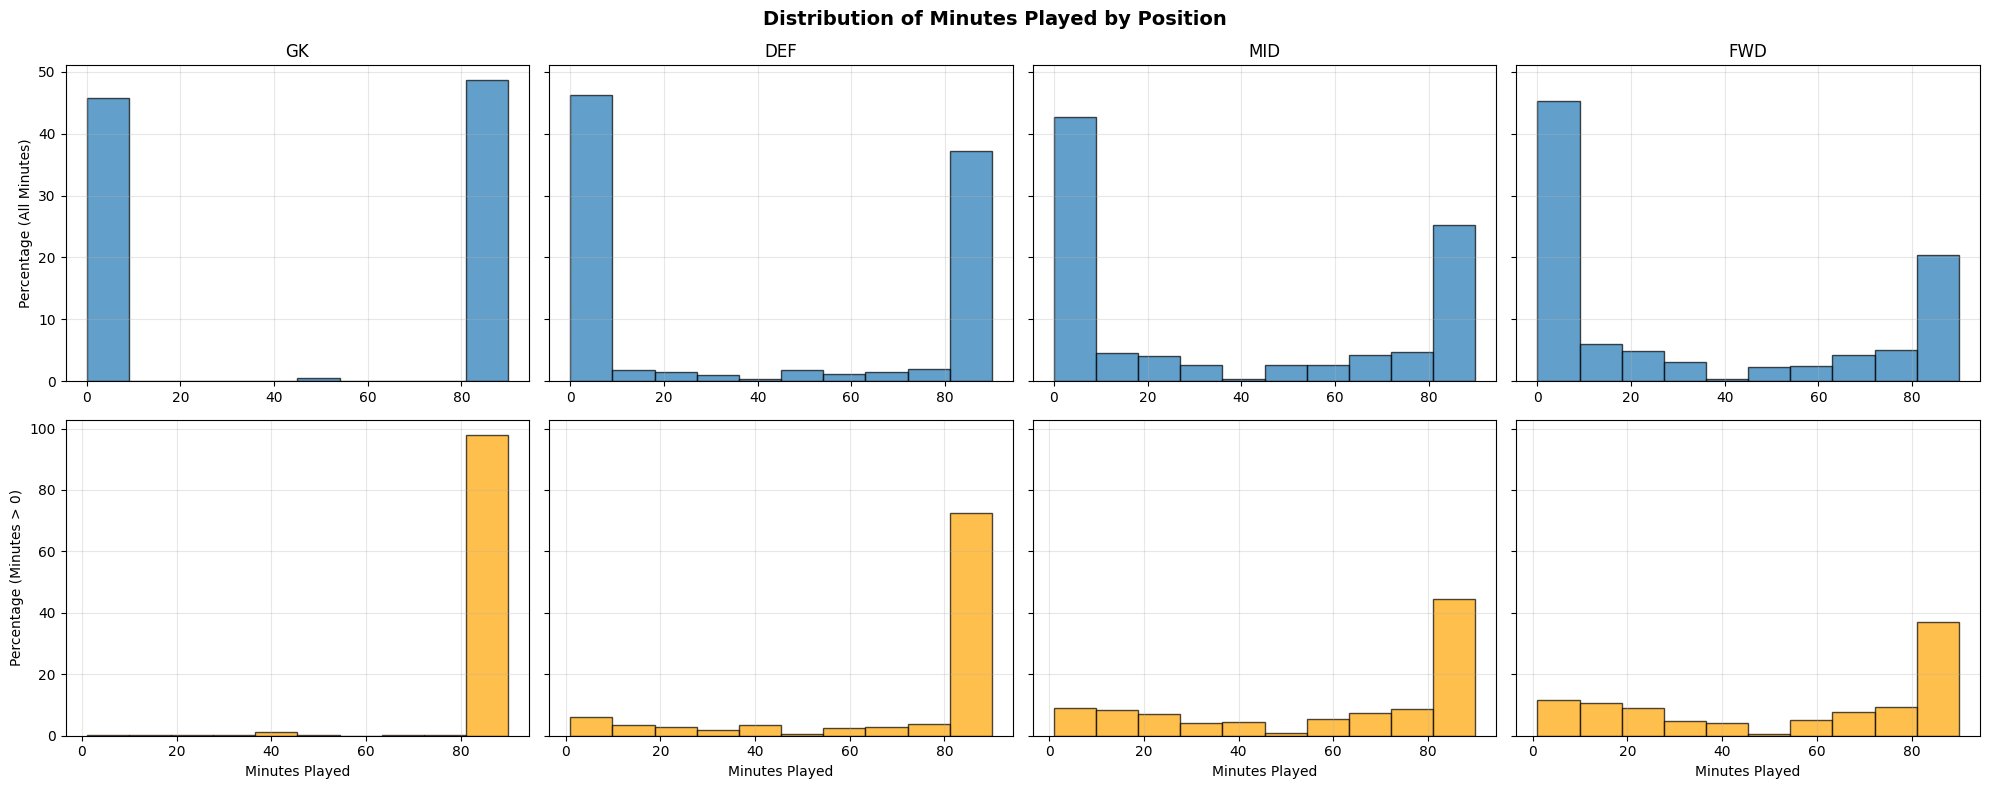

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.354


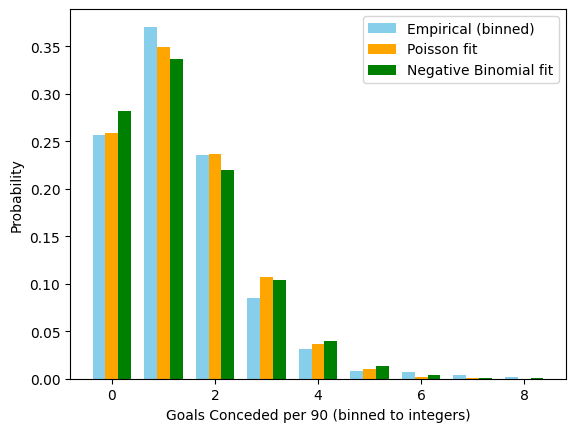

Mean: 1.345, Variance: 1.512
Overdispersion ratio (Var/Mean): 1.124
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.258


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.223


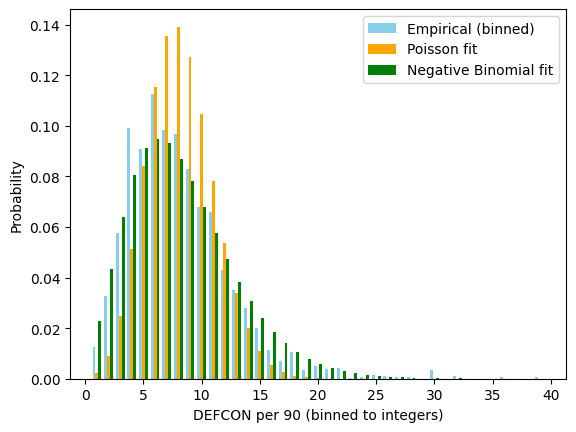

Mean: 8.214, Variance: 21.030
Overdispersion ratio (Var/Mean): 2.560
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [21]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.200


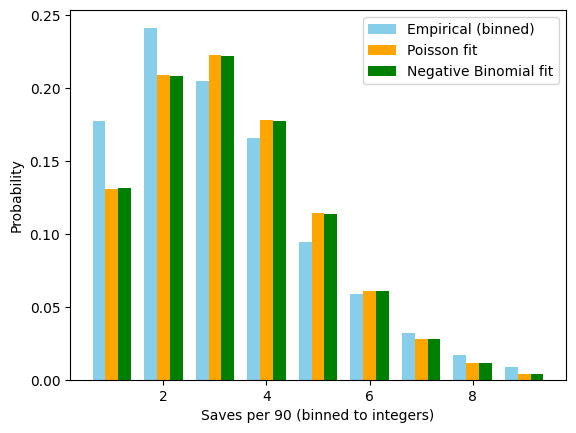

Mean: 3.200, Variance: 3.231
Overdispersion ratio (Var/Mean): 1.010
✅ Poisson assumption looks reasonable.


In [22]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [23]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [24]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [25]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    6041.000000
mean       60.785180
std        20.464859
min        15.245438
25%        42.481652
50%        62.449368
75%        80.170858
max        89.951668
Name: mins_pred, dtype: float64

In [26]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    5663.000000
mean        0.161058
std         0.139961
min         0.025781
25%         0.052452
50%         0.114044
75%         0.223396
max         0.820693
Name: xgp90_pred, dtype: float64

In [27]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    5663.000000
mean        0.099498
std         0.064755
min         0.030796
25%         0.049709
50%         0.076026
75%         0.131578
max         0.381876
Name: xap90_pred, dtype: float64

In [28]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    6041.000000
mean        1.444646
std         0.357003
min         0.474447
25%         1.193520
50%         1.431770
75%         1.699024
max         2.699252
Name: xgcp90_pred, dtype: float64

In [29]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    6041.000000
mean       15.780932
std         3.179479
min         4.395702
25%        13.672130
50%        15.431510
75%        17.754245
max        44.725932
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.441e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):                        0.00
Time:                        13:00:29   Log-Likelihood:                         -39990.
No. Observations:               42438   AIC:                                  7.998e+04
Df Residuals:                   42437   BIC:                                  7.999e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

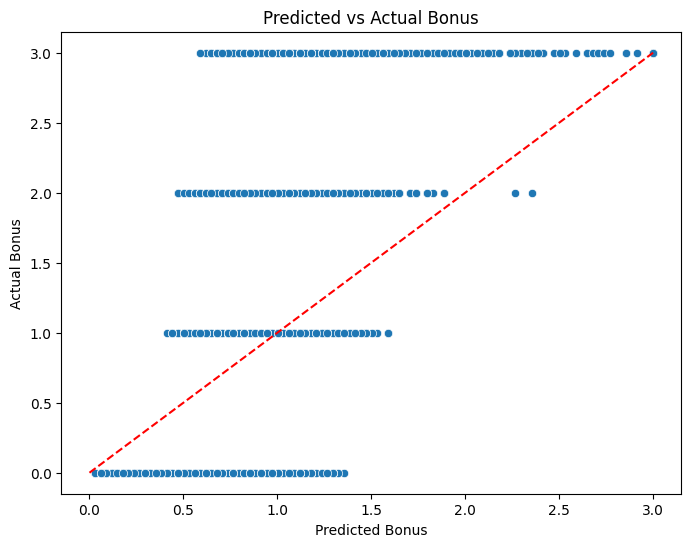

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.458957  0.229374  1.106274  1.946743
FWD           0.332363  0.196758  1.047348  1.707556
GK            0.488662  0.244292  1.115349  2.008297
GKP                NaN       NaN       NaN       NaN
MID           0.396811  0.244941  1.049179  1.824334


C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [32]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    378.000000
mean       3.076007
std        0.641792
min        1.176242
25%        2.651034
50%        3.031856
75%        3.450424
max        4.993072
Name: xsavesp90_pred, dtype: float64

In [33]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    5663.000000
mean        7.824427
std         1.882713
min         2.338422
25%         6.778848
50%         7.956362
75%         9.131806
max        14.216978
Name: xdefconp90_pred, dtype: float64

In [34]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129331,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,27.0,West Ham,977.455615,35.087313,0.105481,0.147941,1.826754
129986,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,30.0,Man City,1228.565364,24.889428,0.165658,0.109134,2.200255
129988,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,31.0,Aston Villa,1168.435218,24.889428,0.162063,0.110084,2.119995
129996,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,32.0,Wolves,908.529848,25.900311,0.169450,0.084911,1.193520
129998,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,33.0,Crystal Palace,1043.713830,25.232790,0.155738,0.083043,1.571718


In [35]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
141628,Marc Guiu Paz,252.0,42.0,Chelsea,FWD,20252026.0,27.0,Burnley,890.940966,45.354150,0.820693,0.381022,1.510417
144341,Norberto Bercique Gomes Betuncal,311.0,50.0,Everton,FWD,20252026.0,27.0,Man Utd,1096.195946,34.567923,0.728827,0.176371,1.962944
138301,Jean-Philippe Mateta,283.0,75.0,Crystal Palace,FWD,20252026.0,27.0,Wolves,908.529848,58.790457,0.719689,0.258944,1.344818
144167,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,27.0,Wolves,908.529848,31.096190,0.690481,0.357385,1.976914
135458,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,27.0,Brighton,1057.578227,49.691547,0.682104,0.311227,1.766409
131650,Benjamin Sesko,681.0,72.0,Man Utd,FWD,20252026.0,27.0,Everton,1061.380748,44.712391,0.613709,0.062352,1.475622
134309,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,27.0,Wolves,908.529848,39.761302,0.613035,0.246489,1.408437
130339,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,27.0,Nott'm Forest,1017.056271,39.445349,0.587262,0.315147,1.518818
134391,Eliezer Mayenda Dossou,561.0,52.0,Sunderland,FWD,20252026.0,27.0,Fulham,1038.061320,31.073507,0.557179,0.190771,1.226745
137075,Igor Thiago Nascimento Rodrigues,136.0,70.0,Brentford,FWD,20252026.0,27.0,Brighton,1057.578227,82.246853,0.556014,0.066022,1.370959


In [36]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [37]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [38]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_6440\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_

In [39]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [40]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6041 entries, 0 to 6040
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          6041 non-null   object 
 1   team_name               6041 non-null   object 
 2   team_elo                6041 non-null   float64
 3   element                 6041 non-null   float64
 4   position                6041 non-null   object 
 5   opp_team_name           6041 non-null   object 
 6   opp_team_elo            6041 non-null   float64
 7   season                  6041 non-null   float64
 8   value                   6041 non-null   float64
 9   event                   6041 non-null   float64
 10  mins_pred               6041 non-null   float64
 11  xgp90_pred              5663 non-null   float64
 12  xap90_pred              5663 non-null   float64
 13  xgcp90_pred             6041 non-null   float64
 14  xpoints_mins            6041 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [43]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 27 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
135828,Gabriel dos Santos Magalhães,5.0,27.0,71.0,Arsenal,DEF,Spurs,981.604056,85.784088,1.929459,0.352659,0.387572,2.192028,0.0,-0.125812,0.540355,0.599828,5.876090
139740,Jurriën Timber,8.0,27.0,64.0,Arsenal,DEF,Spurs,981.604056,87.396992,1.939329,0.380571,0.176149,2.303261,0.0,-0.108875,0.540355,0.584583,5.815374
148488,William Saliba,6.0,27.0,61.0,Arsenal,DEF,Spurs,981.604056,86.221233,1.932272,0.243261,0.138159,2.285416,0.0,-0.111484,0.540355,0.576216,5.604196
134765,Enzo Fernández,237.0,27.0,69.0,Chelsea,MID,Burnley,890.940966,83.750990,1.914909,1.026926,0.818481,0.426282,0.0,0.000000,0.513022,0.716415,5.416034
131053,Antoine Semenyo,82.0,27.0,79.0,Man City,MID,Newcastle,1083.811172,86.435757,1.933614,1.481062,0.595413,0.261013,0.0,0.000000,0.513022,0.517960,5.302085
133001,Cole Palmer,235.0,27.0,105.0,Chelsea,MID,Burnley,890.940966,67.771747,1.685071,1.144287,0.590417,0.389392,0.0,0.000000,0.513022,0.885132,5.207320
135458,Fábio Freitas Gouveia Carvalho,123.0,27.0,47.0,Brentford,MID,Brighton,1057.578227,49.691547,1.262920,1.883045,0.515512,0.170946,0.0,0.000000,0.513022,0.817150,5.162594
135516,Florian Wirtz,382.0,27.0,84.0,Liverpool,MID,Nott'm Forest,1017.056271,85.001849,1.924155,1.153491,0.627661,0.407962,0.0,0.000000,0.513022,0.532888,5.159179
133781,Declan Rice,21.0,27.0,75.0,Arsenal,MID,Spurs,981.604056,85.419980,1.927034,0.771850,0.705306,0.519624,0.0,0.000000,0.513022,0.710344,5.147181
132984,Conor Bradley,375.0,27.0,49.0,Liverpool,DEF,Nott'm Forest,1017.056271,67.613386,1.681644,0.912061,0.366901,1.327471,0.0,-0.329043,0.540355,0.557453,5.056841


In [44]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW27 - GW31


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
86,Conor Bradley,336.987992,8.384363,4.443211,1.819302,7.052006,0.0,-1.556946,2.701777,2.963280,25.806995
151,Florian Wirtz,424.927551,9.620199,5.738066,3.196089,1.963144,0.0,0.000000,2.565111,2.700303,25.782912
155,Fábio Freitas Gouveia Carvalho,249.639412,6.337867,8.914945,2.730364,1.107945,0.0,0.000000,2.565111,3.810031,25.466263
489,Virgil van Dijk,411.782055,9.517024,1.621912,0.631810,8.703676,0.0,-1.086753,2.701777,3.142365,25.231812
184,Ibrahima Konaté,436.970363,9.696562,1.553856,0.706699,8.322231,0.0,-1.170520,2.701777,2.907343,24.717948
188,Igor Thiago Nascimento Rodrigues,410.154559,9.502551,10.483948,0.935860,0.000000,0.0,0.000000,1.301988,2.298788,24.523135
133,Enzo Fernández,421.507912,9.595372,4.718091,3.010150,1.381313,0.0,0.000000,2.565111,2.960655,24.230691
64,Bruno Borges Fernandes,426.036457,9.627909,5.060732,2.705904,1.188024,0.0,0.000000,2.565111,2.746456,23.894135
85,Cole Palmer,341.978966,8.491678,5.558629,2.396161,1.277614,0.0,0.000000,2.565111,3.547578,23.836770
355,Mohamed Salah,398.074210,9.383374,5.312927,1.970293,2.019588,0.0,0.000000,2.565111,2.527732,23.779025


In [45]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
155,Fábio Freitas Gouveia Carvalho,597.041105,15.170266,22.051296,6.181020,2.229150,0.0,0.000000,6.156265,8.951883,60.739881
151,Florian Wirtz,1019.940496,23.089283,13.539344,7.095414,3.894725,0.0,0.000000,6.156265,6.390900,60.165931
32,Antoine Semenyo,950.451009,21.267620,16.357126,6.169906,3.473420,0.0,0.000000,5.643243,5.818022,58.729338
188,Igor Thiago Nascimento Rodrigues,984.876085,22.810663,25.018540,2.185814,0.000000,0.0,0.000000,3.124771,5.320789,58.460576
86,Conor Bradley,810.281697,20.155874,10.925419,4.292424,14.385712,0.0,-4.630693,6.484266,6.721895,58.334896
133,Enzo Fernández,1012.582527,23.036184,11.206564,7.452999,3.268186,0.0,0.000000,6.156265,7.039732,58.159930
64,Bruno Borges Fernandes,1022.427496,23.106568,12.143465,6.559742,3.023454,0.0,0.000000,6.156265,6.824238,57.813732
65,Bruno Guimarães Rodriguez Moura,1004.372986,22.973919,11.717345,6.839734,3.091218,0.0,0.000000,6.156265,6.808258,57.586741
142,Ezri Konsa Ngoyo,1048.553742,23.270749,2.938478,1.712153,19.613058,0.0,-2.906049,6.484266,6.192994,57.305647
159,Gabriel dos Santos Magalhães,942.471308,21.216100,3.913098,4.053715,18.325427,0.0,-2.696366,5.943910,6.175947,56.931831


In [46]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': stats_current_gameweek
})

In [47]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [48]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [49]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 6041 new predictions to predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==stats_current_gameweek) & (
    view['event']==stats_current_gameweek+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points
56813,Erling Haaland,27.0,20252026.0,NaN


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
181636,Erling Haaland,13.0,20252026.0,2.0,90.0
181637,Erling Haaland,14.0,20252026.0,14.0,90.0
181638,Erling Haaland,15.0,20252026.0,2.0,68.0
181639,Erling Haaland,16.0,20252026.0,13.0,90.0
181640,Erling Haaland,17.0,20252026.0,16.0,90.0
181641,Erling Haaland,18.0,20252026.0,2.0,90.0
181642,Erling Haaland,19.0,20252026.0,2.0,90.0
181643,Erling Haaland,20.0,20252026.0,2.0,90.0
181644,Erling Haaland,21.0,20252026.0,6.0,90.0
181645,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
26620,Erling Haaland,2026-02-01 11:57:12.353330,38.0,3.209951,NaN
33637,Erling Haaland,2026-02-02 13:38:00.840050,38.0,3.814370,NaN
40654,Erling Haaland,2026-02-03 14:41:19.430154,38.0,3.970624,NaN
47468,Erling Haaland,2026-02-09 12:29:03.939012,38.0,4.614883,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=stats_current_gameweek)&(
                df_preds['event']<=stats_current_gameweek+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 26.0   3.426947
                                                          27.0   3.437517
                                                          28.0   3.421395
                                                          29.0   3.392790
                                                          30.0   3.432445
...                                                                   ...
2026-02-13 13:00:38.658664 26                  20252026.0 27.0   3.419994
                                                          28.0   3.401470
                                                          29.0   3.422350
                                                          30.0   3.449075
                                                          31.0   3.398792

[71 rows x 1 columns]

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [55]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [56]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==25)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,28.500000
min,2026-01-07 16:29:20.849190,26.000000
25%,2026-01-07 16:29:20.849189888,27.000000
50%,2026-01-08 04:37:05.395073024,28.500000
75%,2026-01-08 16:44:49.940955904,30.000000
max,2026-01-08 16:44:49.940956,31.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 33.32 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)